# **Portfolio Allocation with a Carbon Objective**
**Course:** Sustainability Aware Asset Management  
**Semester:** Spring 2025/2026  
**Authors:**
- Alessandro Botti  
- Yoann Klingele  
- Charbel Merhi  
- Andrea Perani  


### Output policy
The notebook writes figures as PNG files and puts the useful tables in one formatted workbook:
`results/final/SAAM_report_ready_outputs.xlsx`


This notebook implements the empirical analysis for the *Sustainability Aware Asset Management* project.
The objective is to construct and evaluate portfolio allocation strategies using financial data and carbon emissions information.


## **Reproducibility**
To reproduce the analysis, please follow the steps below:
- Clone the project repository locally.
- Create the Python environment:
```bash
conda env create -f environment.yml
```
- Activate the environment:
```bash
conda activate saam-project
```
- Select the newly created kernel in the notebook.
- Run all cells sequentially from top to bottom.


## **Part I Standard Portfolio Allocation**
The first part of the project consists of building a portfolio based on the **minimum-variance criterion** and comparing its performance with a **value-weighted benchmark portfolio**.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

def find_project_dir(start=None):
    current = Path.cwd() if start is None else Path(start)
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "cleaned").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project folder containing data/cleaned.")

PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data" / "cleaned"
RESULTS_DIR = PROJECT_DIR / "results"

# Load cleaned datasets
ri_m = pd.read_csv(DATA_DIR / "RI_M_cleaned.csv", sep=";", na_values="N/A")
co2 = pd.read_csv(DATA_DIR / "CO2_S1_cleaned.csv", sep=";", na_values="N/A")
static = pd.read_csv(DATA_DIR / "STATIC_cleaned.csv", sep=";", na_values="N/A")


## 1) Data Cleaning
Data cleaning is necessary to construct a meaningful and implementable investment strategy.
The datasets used in this notebook correspond to cleaned versions of the original Datastream files. The cleaning procedure follows the guidelines provided in the project description and was partly conducted manually in Excel.
The main steps applied during the manual cleaning phase are summarized below:
- **Removal of completely missing firms**  
  Some ISIN codes returned no data in the Datastream output (for example due to incorrect share classes or missing carbon information). Firms with no available observations across the datasets were removed so that all tables contain the same set of companies.
- **Treatment of very low prices in the Return Index**  
  In the total return index datasets (monthly and yearly), prices below **0.5** were treated as missing values. Extremely low prices can generate unrealistic or infinite returns when computing percentage changes.
- **Treatment of delistings**  
  When firms are delisted, Datastream typically reports missing values at the end of the sample.  
  To capture the economic effect of delisting, the following rule was applied in the return index datasets:
  - the first missing observation after the last valid price is replaced with **0**
  - all subsequent observations remain *N/A*
  This ensures that the return in the delisting period corresponds to **âˆ’100%**, reflecting the loss experienced by investors.
- **Handling missing values within the sample**  
  For annual variables such as **revenues** and **COâ‚‚ emissions**, missing observations between two available years were replaced with the previous available value (forward fill). This assumption reflects delayed or incomplete reporting.
- **Accounting variables left unchanged**  
  Accounting variables such as revenues were **not set to zero when firms delist**. Missing accounting data remain recorded as *N/A*, since a delisting event does not necessarily imply that the firmâ€™s revenues fall to zero.
The datasets directly modified during the cleaning process are mainly the **total return index datasets (RI_M and RI_Y)**, while other datasets remain unchanged except for the forward filling of annual reporting gaps.
After these operations, the datasets contain a consistent set of firms and are suitable for the subsequent portfolio construction steps.


The table below reports the number of firms remaining after these initial cleaning operations.


In [2]:
pd.concat([static.head(), static.tail()])


,ISIN,NAME,Country,Region
0,AT000000STR1,STRABAG SE,AT,EUR
1,AT00000VIE62,FLUGHAFEN WIEN,AT,EUR
2,AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR
3,AT0000652011,ERSTE GROUP BANK,AT,EUR
4,AT0000720008,TELEKOM AUSTRIA,AT,EUR
613,SE0020050417,BOLIDEN ORD SHS,SE,EUR
614,US0528001094,AUTOLIV,SE,EUR
615,US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,IL,EUR
616,US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,IL,EUR
617,US91822M5022,VEON ADR 1:25,NL,EUR


Some additional data issues are addressed later when constructing the investment set. These include:
- **Stale prices**  
  Some securities may exhibit long periods with unchanged prices due to illiquidity or lack of trading activity.
- **Insufficient return history**  
  Firms with too few available monthly return observations cannot be used to estimate reliable return moments.
- **Carbon data availability**  
  Since the second part of the project introduces carbon constraints, firms without carbon information must be excluded from the investment universe.
- **Investment time horizon**  
  Portfolio allocation starts in **2014**, after using the period **2004â€“2013** to estimate expected returns and the covariance matrix.
These aspects are addressed in **Section 2.1**, where the investment universe is formally defined.
A more detailed description of the complete cleaning procedure is provided in the report.


Before proceeding with the empirical analysis, we verify that the cleaned datasets contain the same number of firms and reorganize the matrices into a format that is more suitable for portfolio construction.
Note that the COâ‚‚ dataset includes observations for **2025**. These values are retained for carry-forward purposes when computing carbon intensities, but they are not used to construct portfolio allocations for **2026**, since the corresponding monthly return data are not available.


In [3]:
co2.head()


,NAME,ISIN,1999,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246,876651,844209,833816,742063,771799,813242,819934,790336,790336
1,FLUGHAFEN WIEN,AT00000VIE62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796,8455,8958,9648,4745,5663,7567,9027,9847,9847
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027,6270,7696,7455,6392,4827,6049,12403,9375,9375
3,ERSTE GROUP BANK,AT0000652011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22630,27967,27297,29950,24929,21530,20707,18701,16803,16803
4,TELEKOM AUSTRIA,AT0000720008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"14813,3",...,27419,27867,23833,22758,23766,23732,24048,20964,18807,18807


In [4]:
# Read the year labels and convert them to integers
years = pd.to_numeric(co2.columns[2:], errors="raise").astype(int)

# Create a copy of the dataset and assign year labels to the columns
co2_wide = co2.copy()
co2_wide.columns = ["NAME", "ISIN"] + list(years)

# Use ISIN and NAME as identifiers and sort the columns by year
co2_wide = co2_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

# Convert co2 values to numeric format
co2_wide = co2_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

pd.concat([co2_wide.head(), co2_wide.tail()])


,,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246.0,876651.00,844209.00,833816.0,742063.0,771799.00,813242.0,819934.0,790336.0,790336.0
AT00000VIE62,FLUGHAFEN WIEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796.0,8455.00,8958.00,9648.0,4745.0,5663.00,7567.0,9027.0,9847.0,9847.0
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027.0,6270.00,7696.00,7455.0,6392.0,4827.00,6049.0,12403.0,9375.0,9375.0
AT0000652011,ERSTE GROUP BANK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22630.0,27967.00,27297.00,29950.0,24929.0,21530.00,20707.0,18701.0,16803.0,16803.0
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14813.3,29430.22,16027.64,...,27419.0,27867.00,23833.00,22758.0,23766.0,23732.00,24048.0,20964.0,18807.0,18807.0
SE0020050417,BOLIDEN ORD SHS,NaN,NaN,NaN,NaN,NaN,NaN,703000.0,189936.0,413000.00,473000.00,...,594000.0,605000.00,644000.00,598000.0,544000.0,624794.00,629000.0,627845.0,657646.0,657646.0
US0528001094,AUTOLIV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,102103.61,119092.85,107000.0,98000.0,103000.00,102000.0,95000.0,75000.0,75000.0
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13392.0,13392.00,5170.00,4833.0,3854.0,4238.28,4569.0,4569.0,4569.0,4569.0
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,392268.0,458755.00,372604.00,299146.0,290471.0,282044.00,253306.0,242056.0,243603.0,243603.0


In [5]:
ri_m.head()


,NAME,ISIN,31/12/99,31/01/00,29/02/00,31/03/00,28/04/00,31/05/00,30/06/00,31/07/00,...,30/04/25,30/05/25,30/06/25,31/07/25,29/08/25,30/09/25,31/10/25,28/11/25,31/12/25,30/01/26
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"430,27","430,83","479,46","477,35","465,06","461,5","396,65","452,87","481,49","526,88"
1,FLUGHAFEN WIEN,AT00000VIE62,"147,79","156,25","153,83","158,62","137,27","148,95","159,68","151,08",...,"2339,19","2371,03","2478,96","2417,14","2434,84","2425,66","2409,99","2533,4","2591,68","2587,67"
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"113,07","129,28","128,7","123,36","140,73","146,05","158,13","171,78","190,56","215,11"
3,ERSTE GROUP BANK,AT0000652011,"102,94","94,91","97,74","100,5","96,13","97,86","102,06","102,43",...,"1237,75","1536,73","1621,45","1761,42","1818,07","1867,75","1979,03","2087,48","2308,86","2488,84"
4,TELEKOM AUSTRIA,AT0000720008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"343,5","359,25","383,12","360,02","370,54","361,64","360,3","350,11","357,49","360,93"


In [6]:
# Convert the column labels into datetime format
dates = pd.to_datetime(ri_m.columns[2:], format="%d/%m/%y", errors="coerce")

# Create a copy of the return index dataset and assign the date labels
ri_m_wide = ri_m.copy()
ri_m_wide.columns = ["NAME", "ISIN"] + list(dates)

# Use ISIN and NAME as identifiers and sort the columns by date
ri_m_wide = ri_m_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

# Transform the return index values into numeric format
ri_m_wide = ri_m_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

pd.concat([ri_m_wide.head(), ri_m_wide.tail()])


,,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,430.27,430.83,479.46,477.35,465.06,461.50,396.65,452.87,481.49,526.88
AT00000VIE62,FLUGHAFEN WIEN,147.79,156.25,153.83,158.62,137.27,148.95,159.68,151.08,153.35,161.64,...,2339.19,2371.03,2478.96,2417.14,2434.84,2425.66,2409.99,2533.40,2591.68,2587.67
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,113.07,129.28,128.70,123.36,140.73,146.05,158.13,171.78,190.56,215.11
AT0000652011,ERSTE GROUP BANK,102.94,94.91,97.74,100.50,96.13,97.86,102.06,102.43,106.82,102.31,...,1237.75,1536.73,1621.45,1761.42,1818.07,1867.75,1979.03,2087.48,2308.86,2488.84
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,343.50,359.25,383.12,360.02,370.54,361.64,360.30,350.11,357.49,360.93
SE0020050417,BOLIDEN ORD SHS,16.00,15.72,11.76,11.49,8.90,8.70,7.67,6.87,5.99,5.73,...,37.21,37.84,37.53,37.37,41.71,49.32,54.77,58.06,67.73,85.79
US0528001094,AUTOLIV,85.34,77.68,79.83,87.89,82.58,80.52,70.78,71.70,68.13,57.61,...,678.86,753.90,820.48,817.91,909.71,911.70,862.24,877.52,882.80,901.69
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,159.82,113.50,105.00,102.69,66.01,44.01,58.68,48.64,58.68,47.48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,1649.72,1506.25,1985.68,1718.26,2027.13,2483.16,2555.90,2801.43,2796.27,3376.35,...,3867.12,4183.76,4178.77,3852.16,4582.69,5036.47,5106.29,6704.49,7781.60,8497.18


## 2) Minimum-Variance Portfolio Allocation
The return index values are converted into returns using the simple return definition, $R_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1$.
Returns at date *t* are then collected in the vector $R_t = (R_{1,t}, \ldots, R_{N,t})$, where $N$ denotes the number of firms.


In [7]:
# Convert return index values into simple returns by computing percentage changes over time
returns_wide = ri_m_wide.pct_change(axis=1, fill_method=None)

pd.concat([returns_wide.head(), returns_wide.tail()])


,,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.230679,0.001302,0.112875,-0.004401,-0.025746,-0.007655,-0.140520,0.141737,0.063197,0.094270
AT00000VIE62,FLUGHAFEN WIEN,NaN,0.057243,-0.015488,0.031138,-0.134598,0.085088,0.072038,-0.053858,0.015025,0.054059,...,0.040736,0.013612,0.045520,-0.024938,0.007323,-0.003770,-0.006460,0.051208,0.023005,-0.001547
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.041736,0.143363,-0.004486,-0.041492,0.140807,0.037803,0.082711,0.086321,0.109326,0.128831
AT0000652011,ERSTE GROUP BANK,NaN,-0.078007,0.029818,0.028238,-0.043483,0.017996,0.042918,0.003625,0.042859,-0.042221,...,-0.018134,0.241551,0.055130,0.086324,0.032162,0.027326,0.059580,0.054800,0.106051,0.077952
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.135199,0.045852,0.066444,-0.060294,0.029221,-0.024019,-0.003705,-0.028282,0.021079,0.009623
SE0020050417,BOLIDEN ORD SHS,NaN,-0.017500,-0.251908,-0.022959,-0.225413,-0.022472,-0.118391,-0.104302,-0.128093,-0.043406,...,-0.057736,0.016931,-0.008192,-0.004263,0.116136,0.182450,0.110503,0.060069,0.166552,0.266647
US0528001094,AUTOLIV,NaN,-0.089759,0.027678,0.100965,-0.060416,-0.024946,-0.120964,0.012998,-0.049791,-0.154411,...,0.054049,0.110538,0.088314,-0.003132,0.112237,0.002188,-0.054250,0.017721,0.006017,0.021398
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,-0.289826,-0.074890,-0.022000,-0.357192,-0.333283,0.333333,-0.171097,0.206414,-0.190866,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,-0.086966,0.318294,-0.134674,0.179757,0.224963,0.029293,0.096064,-0.001842,0.207448,...,0.009110,0.081880,-0.001193,-0.078159,0.189642,0.099020,0.013863,0.312987,0.160655,0.091958


### 2.1) Investment Set
This section defines the investment sets used to construct the out-of-sample portfolios.
The allocation exercise is carried out from the end of **2013** to the end of **2024**.
At the end of each year (**Y**), the investment set is defined as the set of firms that satisfy the following criteria:
- **Sufficient return history**  
  Firms must have at least **3 years of available monthly returns** over the previous **10-year estimation window**.
- **No stale prices**  
  Firms are excluded if the share of zero monthly returns in the estimation window exceeds **50%**.
- **Carbon data availability**  
  Firms must have carbon data available at the end of year **Y**.
- **Valid December return index observation**  
  Firms must have a valid return index observation at the end of **December of year Y**, so that they can enter the allocation for year **Y + 1**.

Expected returns are computed over the same 120-month window. For the covariance matrix, we use a Ledoit-Wolf shrinkage estimator with a constant-correlation target. The shrinkage coefficient is estimated year by year and reported below.


In [8]:
# Formation years and basic filters for the investable universe.
years = range(2013, 2025)

tau = 120              # 10 years of monthly returns
min_obs = 36           # at least 3 years of available monthly returns
stale_threshold = 0.50 # maximum 50% of zero returns among available observations

common_firms = ri_m_wide.index.intersection(co2_wide.index)

ri_panel = ri_m_wide.loc[common_firms].copy()
co2_panel = co2_wide.loc[common_firms].copy()

ret_panel = ri_panel.pct_change(axis=1, fill_method=None)
ret_panel = ret_panel.replace([np.inf, -np.inf], np.nan)

year_end_dec = {}

for Y in years:
    dec_dates = [d for d in ri_panel.columns if d.year == Y and d.month == 12]
    if len(dec_dates) == 0:
        raise ValueError(f"No December date found for year {Y}")
    year_end_dec[Y] = max(dec_dates)

# Use 120 monthly returns ending at the December formation date.
def get_return_window(panel, end_date, n_returns=120):
    end_loc = panel.columns.get_loc(end_date)

    start_loc = end_loc - n_returns
    if start_loc < 0:
        raise ValueError(f"Not enough price history before {end_date}")

    price_cols = panel.columns[start_loc:end_loc + 1]
    price_window = panel.loc[:, price_cols]

    return_window = price_window.pct_change(axis=1, fill_method=None)
    return_window = return_window.replace([np.inf, -np.inf], np.nan)

    return_window = return_window.iloc[:, 1:]

    return return_window

# Shrink noisy sample covariances toward a constant-correlation target.
def ledoit_wolf_constant_correlation(X):
    T, N = X.shape
    S = X.T @ X / T

    std = np.sqrt(np.diag(S))
    safe_std = np.where(std > 0, std, np.nan)
    corr = S / np.outer(safe_std, safe_std)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr, 0.0)

    rho_bar = corr.sum() / (N * (N - 1)) if N > 1 else 0.0
    F = rho_bar * np.outer(std, std)
    np.fill_diagonal(F, np.diag(S))

    alpha = lw_shrinkage_intensity(X, S, F, T)
    return (1.0 - alpha) * S + alpha * F, alpha


def lw_shrinkage_intensity(X, S, F, T):
    X2 = X ** 2
    phi_mat = (X2.T @ X2) / T - S ** 2
    pi = phi_mat.sum()
    rho = np.trace(phi_mat) / X.shape[1]
    gamma = np.linalg.norm(S - F, "fro") ** 2

    if gamma <= 0:
        return 0.0

    kappa = (pi - rho) / gamma
    return max(0.0, min(1.0, kappa / T))


def compute_cov_matrix(est_window):
    mean_returns = est_window.mean(axis=1)
    # Missing centered returns are set to zero before shrinkage.
    X = est_window.sub(mean_returns, axis=0).fillna(0.0).T.to_numpy(dtype=float)

    sigma, alpha = ledoit_wolf_constant_correlation(X)
    sigma = pd.DataFrame(sigma, index=est_window.index, columns=est_window.index)
    return sigma, alpha

# Investment set filters: return history, non-stale prices, carbon data and valid December RI.
def get_investment_set(Y):

    dec_date = year_end_dec[Y]

    returns_window = get_return_window(ri_panel, dec_date, n_returns=tau)

    n_available = returns_window.notna().sum(axis=1)
    enough_history = n_available >= min_obs

    zero_counts = returns_window.eq(0).sum(axis=1)
    zero_share = zero_counts / n_available.replace(0, np.nan)
    not_stale = zero_share <= stale_threshold

    if Y in co2_panel.columns:
        has_carbon = co2_panel[Y].notna()
    else:
        has_carbon = pd.Series(False, index=co2_panel.index)

    valid_dec_price = ri_panel[dec_date].notna()

    keep = enough_history & not_stale & has_carbon & valid_dec_price

    return common_firms[keep.fillna(False)]

# Store the yearly universe, mean returns and covariance matrix used by later optimizers.
investment_sets = {}
mu_dict = {}
sigma_dict = {}
shrinkage_alpha_by_year = {}

for Y in years:

    eligible = get_investment_set(Y)
    dec_date = year_end_dec[Y]

    est_window = get_return_window(ri_panel.loc[eligible], dec_date, n_returns=tau)

    investment_sets[Y] = eligible

    mu_dict[Y] = est_window.mean(axis=1)
    sigma, alpha = compute_cov_matrix(est_window)
    sigma_dict[Y] = sigma
    shrinkage_alpha_by_year[Y] = alpha

shrinkage_alpha_summary = pd.Series(shrinkage_alpha_by_year, name="alpha")
display(shrinkage_alpha_summary.to_frame())


,alpha
2013,1.000000
2014,1.000000
2015,1.000000
2016,0.978952
2017,0.975131
2018,0.806916
2019,0.470886
2020,0.792187
2021,0.850315
2022,0.799871


The table below reports the size of the investment set over time, together with the dimensions of the expected return vector and covariance matrix.


In [9]:
summary_table = pd.DataFrame({
    "Number of firms": {Y: len(investment_sets[Y]) for Y in years},
    "Expected return vector": {Y: mu_dict[Y].shape for Y in years},
    "Covariance matrix": {Y: sigma_dict[Y].shape for Y in years},
})

summary_table


,Number of firms,Expected return vector,Covariance matrix
2013,477,"(477,)","(477, 477)"
2014,493,"(493,)","(493, 493)"
2015,509,"(509,)","(509, 509)"
2016,515,"(515,)","(515, 515)"
2017,529,"(529,)","(529, 529)"
2018,549,"(549,)","(549, 549)"
2019,574,"(574,)","(574, 574)"
2020,593,"(593,)","(593, 593)"
2021,600,"(600,)","(600, 600)"
2022,592,"(592,)","(592, 592)"


Overall, the size of the investment set increases over most of the sample period, reflecting improved data availability over time, before declining slightly in the final years.


The outputs below report the estimated expected return vectors for **2013** and **2024**, corresponding to the first and last portfolio formation years.


In [10]:
mu_dict[2013]


ISIN          NAME                                        
AT000000STR1  STRABAG SE                                     -0.000342
AT0000606306  RAIFFEISEN BANK INTL.                           0.009210
AT0000652011  ERSTE GROUP BANK                                0.013121
AT0000720008  TELEKOM AUSTRIA                                 0.003181
AT0000743059  OMV                                             0.017857
                                                                ...   
SE0018012635  WIHLBORGS FASTIGHETER                           0.017928
SE0020050417  BOLIDEN ORD SHS                                 0.026865
US70211M1099  PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23    0.011928
US8816242098  TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1          0.005449
US91822M5022  VEON ADR 1:25                                   0.005762
Length: 477, dtype: float64

In [11]:
mu_dict[2024]


ISIN          NAME                                  
AT000000STR1  STRABAG SE                                0.013637
AT00000VIE62  FLUGHAFEN WIEN                            0.011278
AT0000606306  RAIFFEISEN BANK INTL.                     0.011045
AT0000652011  ERSTE GROUP BANK                          0.016418
AT0000720008  TELEKOM AUSTRIA                           0.007144
                                                          ...   
SE0018012635  WIHLBORGS FASTIGHETER                     0.012680
SE0020050417  BOLIDEN ORD SHS                           0.013173
US0528001094  AUTOLIV                                   0.008381
US8816242098  TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1    0.002201
US91822M5022  VEON ADR 1:25                             0.009034
Length: 564, dtype: float64

The outputs below report the covariance matrices for the first five firms in the **2013** and **2024** investment sets.


In [12]:
sigma_dict[2013].iloc[:5, :5]


,ISIN,AT000000STR1,AT0000606306,AT0000652011,AT0000720008,AT0000743059
,NAME,STRABAG SE,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA,OMV
ISIN,NAME,,,,,
AT000000STR1,STRABAG SE,0.012218,0.006202,0.006614,0.003980,0.004858
AT0000606306,RAIFFEISEN BANK INTL.,0.006202,0.017680,0.007956,0.004788,0.005844
AT0000652011,ERSTE GROUP BANK,0.006614,0.007956,0.020110,0.005106,0.006232
AT0000720008,TELEKOM AUSTRIA,0.003980,0.004788,0.005106,0.007283,0.003751
AT0000743059,OMV,0.004858,0.005844,0.006232,0.003751,0.010849


In [13]:
sigma_dict[2024].iloc[:5, :5]


,ISIN,AT000000STR1,AT00000VIE62,AT0000606306,AT0000652011,AT0000720008
,NAME,STRABAG SE,FLUGHAFEN WIEN,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA
ISIN,NAME,,,,,
AT000000STR1,STRABAG SE,0.004674,0.002099,0.003039,0.002771,0.001415
AT00000VIE62,FLUGHAFEN WIEN,0.002099,0.005941,0.003260,0.003005,0.001567
AT0000606306,RAIFFEISEN BANK INTL.,0.003039,0.003260,0.012730,0.004996,0.002492
AT0000652011,ERSTE GROUP BANK,0.002771,0.003005,0.004996,0.010191,0.002151
AT0000720008,TELEKOM AUSTRIA,0.001415,0.001567,0.002492,0.002151,0.003104


### 2.2) Minimum-Variance Portfolio Allocation
This section implements the long-only minimum-variance portfolio for each formation year.
At the end of year **Y**, the Ledoit-Wolf covariance matrix from Section 2.1 is used to solve a constrained minimum-variance problem with full-investment and non-negativity constraints.
The resulting portfolio is held out of sample during year **Y + 1**. Within the year, weights drift passively with asset returns. Delisting events are treated as a **-100% return** in the first missing month after the last valid observation.
The outputs include yearly investment set sizes, portfolio weights, monthly returns and summary statistics.


In [14]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from scipy.optimize import minimize

warnings.filterwarnings("ignore", category=RuntimeWarning)

required_objects = ["years", "investment_sets", "year_end_dec", "ri_panel", "ret_panel", "sigma_dict", "DATA_DIR", "RESULTS_DIR"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Section 2.1 must be run first. Missing object: {obj}")

data_dir = DATA_DIR
# Risk-free rates are aligned monthly for Sharpe ratios.
rf_file = data_dir / "RF.csv"

output_dir = RESULTS_DIR / "outputs_minvar"
output_dir.mkdir(parents=True, exist_ok=True)

ridge = 1e-8
solver_maxiter = 2000
ftol = 1e-12
csv_sep = ";"

# Long-only minimum-variance optimizer for one formation year.
def solve_minvar(cov_matrix):
    n = cov_matrix.shape[0]

    if n == 0:
        raise ValueError("Covariance matrix is empty.")
    if n == 1:
        return pd.Series([1.0], index=cov_matrix.index)

    Sigma = cov_matrix.to_numpy(dtype=float)
    Sigma = Sigma + ridge * np.eye(n)

    x0 = np.repeat(1 / n, n)

    def objective(w):
        return float(w @ Sigma @ w)

    def objective_grad(w):
        return 2.0 * Sigma @ w

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1.0,
            "jac": lambda w: np.ones_like(w),
        }
    ]
    bounds = [(0.0, 1.0)] * n

    res = minimize(
        objective,
        x0=x0,
        jac=objective_grad,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": solver_maxiter, "ftol": ftol, "disp": False},
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=cov_matrix.index)
    w = w / w.sum()
    return w

def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1.0
    return drawdown.min()

rf_raw = pd.read_csv(rf_file, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])

if rf_raw.shape[1] < 2:
    raise ValueError("RF.csv must contain at least one date column and one RF column.")

rf = rf_raw.copy()
rf.columns = ["date_code", "RF"]

rf["date_code"] = rf["date_code"].astype(str).str.strip()
rf["date"] = pd.to_datetime(rf["date_code"], format="%Y%m") + pd.offsets.MonthEnd(0)

rf["RF"] = pd.to_numeric(
    rf["RF"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
) / 100.0

rf_series = rf.set_index("date")["RF"].sort_index()
rf_series = rf_series.loc[rf_series.index <= pd.Timestamp("2025-12-31")]

if len(rf_series.dropna()) > 0 and rf_series.dropna().median() > 1:
    rf_series = rf_series / 100.0

delist_pattern = re.compile(r"DEAD|DELIST|SUSP", re.IGNORECASE)
# Delisting and suspension events are treated as a -100% return in the event month.
delist_event_month = {}

for asset in ri_panel.index:
    isin, name = asset

    if not delist_pattern.search(name):
        continue

    ri_series = ri_panel.loc[asset]
    valid_dates = ri_series.dropna().index

    if len(valid_dates) == 0:
        continue

    last_valid_date = valid_dates.max()
    future_dates = [d for d in ri_panel.columns if d > last_valid_date]

    if len(future_dates) == 0:
        continue

    first_missing_date = future_dates[0]

    if pd.isna(ri_series[first_missing_date]):
        delist_event_month[asset] = first_missing_date


investment_set_rows = []
weights_long_rows = []
oos_rows = []
mv_weights = {}

# Form a portfolio at each year-end and hold it through the following calendar year.
for Y in years:

    eligible = investment_sets[Y]
    dec_date = year_end_dec[Y]

    investment_set_rows.append({
        "formation_year": Y,
        "n_eligible": len(eligible)
    })

    if len(eligible) == 0:
        continue

    Sigma = sigma_dict[Y].copy()

    valid_assets = Sigma.index[Sigma.notna().all(axis=1)]
    Sigma = Sigma.loc[valid_assets, valid_assets]

    if Sigma.empty:
        continue

    w0 = solve_minvar(Sigma)
    mv_weights[Y] = w0

    for (isin, name), w in w0.items():
        weights_long_rows.append({
            "formation_year": Y,
            "oos_year": Y + 1,
            "ISIN": isin,
            "NAME": name,
            "weight": w
        })

    oos_months = sorted([d for d in ret_panel.columns if d.year == Y + 1])
    if len(oos_months) == 0:
        continue

    current_weights = w0.copy()

    for dt in oos_months:
        r_t = ret_panel.loc[current_weights.index, dt].copy()

        forced_delist_assets = []
        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        # Other missing returns are ignored for that month.
        valid = r_t.notna() & current_weights.notna()
        r_t = r_t[valid]
        w_t = current_weights[valid]

        if len(w_t) == 0:
            oos_rows.append({
                "date": dt,
                "formation_year": Y,
                "oos_year": Y + 1,
                "portfolio_return": np.nan
            })
            continue

        w_t = w_t / w_t.sum()

        rp_t = float((w_t * r_t).sum())

        oos_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": rp_t
        })

        # Within the year, weights drift with realized asset returns.
        denom = 1.0 + rp_t

        if abs(denom) > 1e-12:
            current_weights = w_t * (1.0 + r_t) / denom
            total = current_weights.sum()

            if abs(total) > 1e-12:
                current_weights = current_weights / total
            else:
                current_weights = pd.Series(
                    np.repeat(1 / len(w_t), len(w_t)),
                    index=w_t.index
                )
        else:
            current_weights = pd.Series(
                np.repeat(1 / len(w_t), len(w_t)),
                index=w_t.index
            )

investment_set_sizes = pd.DataFrame(investment_set_rows)
weights_by_year_long = pd.DataFrame(weights_long_rows)

minvar_monthly_returns = pd.DataFrame(oos_rows).sort_values("date").reset_index(drop=True)

if minvar_monthly_returns.empty:
    raise ValueError("No out-of-sample minimum-variance returns were produced.")

minvar_monthly_returns["date"] = pd.to_datetime(minvar_monthly_returns["date"])
minvar_monthly_returns = minvar_monthly_returns[
    (minvar_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (minvar_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

minvar_monthly_returns["cumulative_index"] = (
    1.0 + minvar_monthly_returns["portfolio_return"]
).cumprod()

minvar_cumulative_returns = minvar_monthly_returns[
    ["date", "formation_year", "oos_year", "portfolio_return", "cumulative_index"]
].copy()

full_months = pd.date_range("2014-01-31", "2025-12-31", freq="ME")
template_ready = pd.DataFrame({"date": full_months})
template_ready = template_ready.merge(
    minvar_monthly_returns[["date", "portfolio_return"]],
    on="date",
    how="left"
)
template_ready["date_str"] = template_ready["date"].dt.strftime("%Y-%m")
template_ready = template_ready[["date_str", "portfolio_return"]]

r = minvar_monthly_returns.set_index("date")["portfolio_return"].sort_index().dropna()

r_month = r.copy()
r_month.index = r_month.index.to_period("M")

rf_month = rf_series.copy()
rf_month.index = rf_month.index.to_period("M")

rf_aligned = rf_month.reindex(r_month.index)

missing_rf = rf_aligned.isna().sum()

if missing_rf > 0:
    raise ValueError("Some monthly RF observations are still missing after month-based alignment.")

excess = r_month - rf_aligned

ann_mean = 12 * r_month.mean()
ann_vol = np.sqrt(12) * r_month.std(ddof=1)

if len(excess.dropna()) >= 2 and excess.std(ddof=1) != 0:
    sharpe = np.sqrt(12) * excess.mean() / excess.std(ddof=1)
else:
    sharpe = np.nan

# Summarize out-of-sample performance from 2014 to 2025.
summary_stats = pd.DataFrame({
    "metric": [
        "Annualized mean return",
        "Annualized volatility",
        "Sharpe ratio",
        "Minimum monthly return",
        "Maximum monthly return",
        "Final cumulative index",
        "Maximum drawdown",
        "Number of monthly observations",
    ],
    "value": [
        ann_mean,
        ann_vol,
        sharpe,
        r.min(),
        r.max(),
        minvar_monthly_returns["cumulative_index"].iloc[-1],
        max_drawdown(minvar_monthly_returns.set_index("date")["cumulative_index"]),
        int(r.notna().sum()),
    ]
})

mv_oos_returns = minvar_monthly_returns.set_index("date")["portfolio_return"].sort_index()

display(summary_stats)
display(investment_set_sizes)


,metric,value
0,Annualized mean return,0.057979
1,Annualized volatility,0.135722
2,Sharpe ratio,0.298178
3,Minimum monthly return,-0.116372
4,Maximum monthly return,0.103969
5,Final cumulative index,1.792918
6,Maximum drawdown,-0.276646
7,Number of monthly observations,144.000000


,formation_year,n_eligible
0,2013,477
1,2014,493
2,2015,509
3,2016,515
4,2017,529
5,2018,549
6,2019,574
7,2020,593
8,2021,600
9,2022,592


### 2.3 Comparison with the value-weighted portfolio
This section compares the out-of-sample minimum-variance portfolio to a value-weighted benchmark.
The benchmark uses previous-month market capitalizations and the same yearly investment set as the minimum-variance portfolio. Performance is evaluated over **2014-2025** using annualized arithmetic return, annualized volatility, Sharpe ratio, final cumulative index, maximum drawdown, and monthly return extremes.


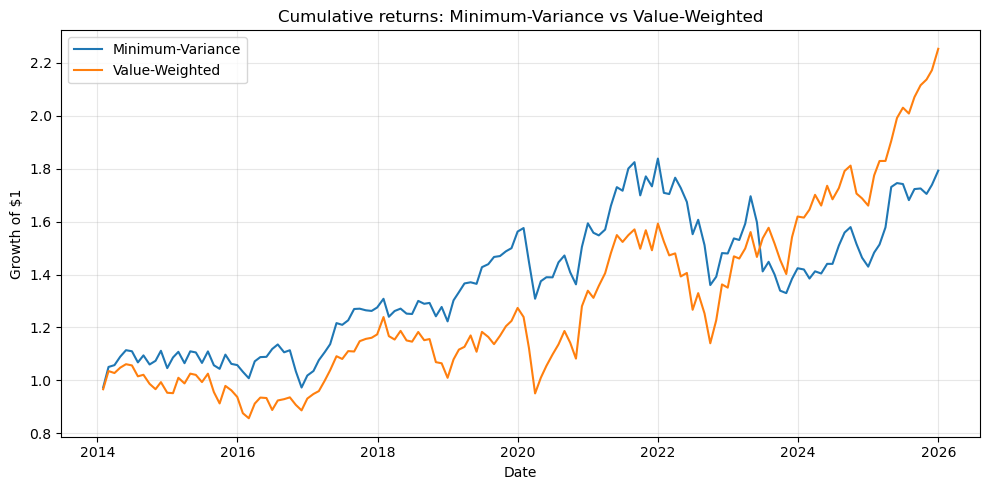

,Annualized mean return,Annualized volatility,Sharpe ratio,Minimum monthly return,Maximum monthly return,Final cumulative index,Maximum drawdown,Number of monthly observations
Minimum-Variance,0.057979,0.135722,0.298178,-0.116372,0.103969,1.792918,-0.276646,144.0
Value-Weighted,0.080346,0.158463,0.397584,-0.152973,0.182863,2.253411,-0.283950,144.0


In [15]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build the value-weighted benchmark on the same universe and sample period.
required_objects = [
    "years",
    "investment_sets",
    "year_end_dec",
    "ri_panel",
    "ret_panel",
    "mv_oos_returns",
    "rf_series",
    "DATA_DIR",
    "RESULTS_DIR"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Missing object from previous sections: {obj}")

data_dir = DATA_DIR
mv_file = data_dir / "MV_M_cleaned.csv"

output_dir = RESULTS_DIR / "outputs_vw"
output_dir.mkdir(parents=True, exist_ok=True)

csv_sep = ";"

def parse_calendar_date_headers(columns):
    cols = pd.Index(columns).astype(str).str.strip()
    return [pd.to_datetime(c, dayfirst=True) for c in cols]

def to_numeric_panel(df):
    return df.apply(
        lambda col: pd.to_numeric(
            col.astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )
    )

# Use the same performance definitions as for the minimum-variance portfolio.
def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1.0
    return drawdown.min()

def perf_stats(r, rf):

    r = r.replace([np.inf, -np.inf], np.nan).dropna().copy()

    r_month = r.copy()
    r_month.index = r_month.index.to_period("M")

    rf_month = rf.copy()
    rf_month.index = rf_month.index.to_period("M")

    rf_aligned = rf_month.reindex(r_month.index)

    if rf_aligned.isna().sum() > 0:
        raise ValueError("Some RF observations are missing after monthly alignment.")

    excess = r_month - rf_aligned

    ann_mean = 12 * r_month.mean()
    ann_vol = np.sqrt(12) * r_month.std(ddof=1)

    if excess.std(ddof=1) != 0:
        sharpe = np.sqrt(12) * excess.mean() / excess.std(ddof=1)
    else:
        sharpe = np.nan

    cumulative_index = (1 + r).cumprod()

    return pd.Series({
        "Annualized mean return": ann_mean,
        "Annualized volatility": ann_vol,
        "Sharpe ratio": sharpe,
        "Minimum monthly return": r.min(),
        "Maximum monthly return": r.max(),
        "Final cumulative index": cumulative_index.iloc[-1],
        "Maximum drawdown": max_drawdown(cumulative_index),
        "Number of monthly observations": r.shape[0]
    })

mv_raw = pd.read_csv(mv_file, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])

mv_dates = parse_calendar_date_headers(list(mv_raw.columns[2:]))

mv_panel = mv_raw.copy()
mv_panel.columns = ["NAME", "ISIN"] + mv_dates
mv_panel = mv_panel.set_index(["ISIN", "NAME"])

mv_panel = to_numeric_panel(mv_panel)

mv_panel = mv_panel.loc[:, mv_panel.columns <= pd.Timestamp("2025-12-31")]

common_mv_firms = mv_panel.index.intersection(ret_panel.index).intersection(ri_panel.index)
mv_panel = mv_panel.loc[common_mv_firms]


delist_pattern = re.compile(r"DEAD|DELIST|SUSP", re.IGNORECASE)
# Apply the same delisting convention as in the minimum-variance simulation.
delist_event_month = {}

for asset in ri_panel.index:

    isin, name = asset

    if not delist_pattern.search(name):
        continue

    ri_series = ri_panel.loc[asset]
    valid_dates = ri_series.dropna().index

    if len(valid_dates) == 0:
        continue

    last_valid_date = valid_dates.max()
    future_dates = [d for d in ri_panel.columns if d > last_valid_date]

    if len(future_dates) == 0:
        continue

    first_missing_date = future_dates[0]

    if pd.isna(ri_series[first_missing_date]):
        delist_event_month[asset] = first_missing_date

# Monthly benchmark weights use the previous month market capitalization.
vw_rows = []

all_months = sorted(ret_panel.columns)

for Y in years:


    eligible = investment_sets[Y]

    oos_months = [d for d in all_months if d.year == Y + 1]
    if len(oos_months) == 0:
        continue

    for dt in oos_months:

        current_loc = all_months.index(dt)
        prev_date = all_months[current_loc - 1]

        caps_t = mv_panel.loc[eligible, prev_date].copy()
        r_t = ret_panel.loc[eligible, dt].copy()

        forced_delist_assets = []

        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        valid = (
            caps_t.notna()
            & np.isfinite(caps_t)
            & (caps_t > 0)
            & r_t.notna()
            & np.isfinite(r_t)
            & (r_t >= -1.0)
        )

        caps_t = caps_t[valid]
        r_t = r_t[valid]

        if len(caps_t) == 0:
            port_ret = np.nan
        else:
            w_t = caps_t / caps_t.sum()
            port_ret = float((w_t * r_t).sum())

        vw_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": port_ret
        })

vw_monthly_returns = pd.DataFrame(vw_rows).sort_values("date").reset_index(drop=True)

if vw_monthly_returns.empty:
    raise ValueError("No value-weighted returns were produced.")

vw_monthly_returns["date"] = pd.to_datetime(vw_monthly_returns["date"])

vw_monthly_returns = vw_monthly_returns[
    (vw_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (vw_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

vw_monthly_returns["cumulative_index"] = (1.0 + vw_monthly_returns["portfolio_return"]).cumprod()

vw_oos_returns = vw_monthly_returns.set_index("date")["portfolio_return"].sort_index()

# Compare both strategies on the same out-of-sample months.
comparison_returns = pd.concat(
    [
        mv_oos_returns.rename("Minimum-Variance"),
        vw_oos_returns.rename("Value-Weighted")
    ],
    axis=1
).sort_index()

comparison_cumulative = (1.0 + comparison_returns).cumprod()

comparison_stats = pd.concat(
    [
        perf_stats(comparison_returns["Minimum-Variance"], rf_series).rename("Minimum-Variance"),
        perf_stats(comparison_returns["Value-Weighted"], rf_series).rename("Value-Weighted")
    ],
    axis=1
).T

plt.figure(figsize=(10, 5))

plt.plot(
    comparison_cumulative.index,
    comparison_cumulative["Minimum-Variance"],
    label="Minimum-Variance"
)

plt.plot(
    comparison_cumulative.index,
    comparison_cumulative["Value-Weighted"],
    label="Value-Weighted"
)

plt.title("Cumulative returns: Minimum-Variance vs Value-Weighted")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

display(comparison_stats)


### Interpretation of the results
The value-weighted portfolio delivers a higher annualized return and Sharpe ratio than the minimum-variance portfolio over the **2014-2025** out-of-sample period, but with higher volatility and larger drawdowns.
The minimum-variance portfolio has a smoother return path and smaller downside shocks, which is consistent with its risk-minimization objective.


## **Part II - Portfolio Allocation with Carbon Emission Reduction**


## 3) Allocation with a 50% Reduction in Carbon Emissions
This section adds the climate objective while keeping the same European investment universe as in Part I. The carbon variable is **Scope 1 emissions**, as assigned to our group.

We study two 50% reduction strategies:
- a minimum-variance portfolio with a 50% lower carbon footprint than the unconstrained minimum-variance portfolio;
- a value-weighted strategy with a 50% lower carbon footprint than the benchmark, obtained by minimizing tracking error.


### 3.1) Carbon Emissions
This subsection prepares the annual carbon variables used in the rest of the analysis. Since revenues are reported in thousands USD, they are divided by 1000 before computing carbon intensity:

$$
CI_{i,Y} = \frac{E_{i,Y}}{Rev_{i,Y}/1000}
$$

We then compute two portfolio-level indicators:

$$
WACI_Y^p = \sum_i \alpha_{i,Y} CI_{i,Y}
$$

$$
CF_Y^p = \sum_i \alpha_{i,Y}\frac{E_{i,Y}}{Cap_{i,Y}}
$$

The notebook reports these indicators by year and lists the main WACI contributors with firm names and ISIN codes.


In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

required_objects = [
    "years", "investment_sets", "sigma_dict", "ret_panel", "ri_panel",
    "mv_weights", "mv_oos_returns", "vw_oos_returns", "rf_series", "perf_stats",
    "DATA_DIR", "RESULTS_DIR"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Part I must be run first. Missing object: {obj}")

data_dir = DATA_DIR
output_dir = RESULTS_DIR / "outputs_carbon"
output_dir.mkdir(parents=True, exist_ok=True)

csv_sep = ";"
ridge = 1e-8
solver_maxiter = 2000
ftol = 1e-12
starting_wealth_musd = 1.0

# Annual carbon, revenue and market-cap panels are aligned by firm and year.
def load_annual_panel(file_name):
    raw = pd.read_csv(data_dir / file_name, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])
    panel = raw.copy()
    panel.columns = ["NAME", "ISIN"] + [int(c) for c in panel.columns[2:]]
    panel = panel.set_index(["ISIN", "NAME"])
    panel = panel.apply(lambda col: pd.to_numeric(col.astype(str).str.replace(",", ".", regex=False), errors="coerce"))

    return panel.ffill(axis=1)

co2_s1_y = load_annual_panel("CO2_S1_cleaned.csv")
revenue_y = load_annual_panel("REVENUE_Y_cleaned.csv")
market_cap_y = load_annual_panel("MV_Y_cleaned.csv")

common_carbon_firms = (
    co2_s1_y.index
    .intersection(revenue_y.index)
    .intersection(market_cap_y.index)
    .intersection(ret_panel.index)
)

co2_s1_y = co2_s1_y.loc[common_carbon_firms]
revenue_y = revenue_y.loc[common_carbon_firms]
market_cap_y = market_cap_y.loc[common_carbon_firms]


def normalize_weights(weights):
    w = weights.replace([np.inf, -np.inf], np.nan).dropna().copy()
    w = w[w > 0]
    if w.empty:
        return w
    return w / w.sum()

# Carbon inputs are converted to the units used in the project formulas.
def get_carbon_inputs(asset_index, Y):
    assets = pd.Index(asset_index)

    emissions = co2_s1_y.reindex(assets)[Y]
    revenues = revenue_y.reindex(assets)[Y]
    market_caps = market_cap_y.reindex(assets)[Y]

    valid = (
        emissions.notna()
        & revenues.notna()
        & market_caps.notna()
        & np.isfinite(emissions)
        & np.isfinite(revenues)
        & np.isfinite(market_caps)
        & (revenues > 0)
        & (market_caps > 0)
    )

    emissions = emissions[valid]
    revenues = revenues[valid]
    market_caps = market_caps[valid]

    return pd.DataFrame({
        "emissions_scope1": emissions,
        "revenue_musd": revenues / 1000.0,
        "market_cap_musd": market_caps,
        "carbon_intensity": emissions / (revenues / 1000.0),
        "carbon_footprint_coeff": emissions / market_caps,
    })

# WACI uses revenue scaling; carbon footprint uses market-cap scaling.
def compute_carbon_metrics(weights, Y, strategy, wealth_musd=1.0):
    weights = normalize_weights(weights)
    carbon_inputs = get_carbon_inputs(weights.index, Y)

    w = weights.reindex(carbon_inputs.index).dropna()
    carbon_inputs = carbon_inputs.loc[w.index]
    w = w / w.sum()

    waci = float((w * carbon_inputs["carbon_intensity"]).sum())
    carbon_footprint = float((w * carbon_inputs["carbon_footprint_coeff"]).sum())

    return {
        "strategy": strategy,
        "formation_year": Y,
        "wealth_musd": wealth_musd,
        "WACI": waci,
        "carbon_footprint": carbon_footprint,
        "attributed_emissions_tonnes": wealth_musd * carbon_footprint,
        "n_assets_used": int(w.shape[0]),
        "n_assets_dropped": int(weights.shape[0] - w.shape[0]),
    }

def compute_waci_contributions(weights, Y, strategy):
    weights = normalize_weights(weights)
    carbon_inputs = get_carbon_inputs(weights.index, Y)
    w = weights.reindex(carbon_inputs.index).dropna()
    carbon_inputs = carbon_inputs.loc[w.index]
    w = w / w.sum()

    out = carbon_inputs.copy()
    out["weight"] = w
    out["WACI_contribution"] = out["weight"] * out["carbon_intensity"]
    out = out.reset_index()
    out["formation_year"] = Y
    out["strategy"] = strategy
    return out.sort_values("WACI_contribution", ascending=False)

def get_annual_vw_weights(Y, asset_index):
    caps = market_cap_y.reindex(asset_index)[Y]
    caps = caps.replace([np.inf, -np.inf], np.nan).dropna()
    caps = caps[caps > 0]
    if caps.empty:
        return caps
    return caps / caps.sum()

def wealth_by_formation_year(monthly_returns):
    wealth = {}
    current_wealth = starting_wealth_musd
    returns = monthly_returns.dropna().copy()

    for Y in years:
        wealth[Y] = current_wealth
        year_returns = returns[returns.index.year == Y + 1]
        current_wealth = current_wealth * float((1.0 + year_returns).prod())

    return wealth

def compute_active_share(portfolio_weights, benchmark_weights):
    assets = portfolio_weights.index.union(benchmark_weights.index)
    w = portfolio_weights.reindex(assets).fillna(0.0)
    b = benchmark_weights.reindex(assets).fillna(0.0)
    return 0.5 * float((w - b).abs().sum())

def compute_ex_post_tracking_error(portfolio_returns, benchmark_returns):
    aligned = pd.concat(
        [
            portfolio_returns.rename("portfolio"),
            benchmark_returns.rename("benchmark"),
        ],
        axis=1,
    ).dropna()

    tracking_difference = aligned["portfolio"] - aligned["benchmark"]
    return np.sqrt(12) * tracking_difference.std(ddof=1)

mv_wealth_by_year = wealth_by_formation_year(mv_oos_returns)
vw_wealth_by_year = wealth_by_formation_year(vw_oos_returns)

# Baseline carbon metrics are computed for the unconstrained MV and VW portfolios.
baseline_metric_rows = []
baseline_contribution_rows = []
vw_weights_by_year = {}

for Y in years:
    eligible = investment_sets[Y]
    mv_w = mv_weights[Y]
    vw_w = get_annual_vw_weights(Y, eligible)
    vw_weights_by_year[Y] = vw_w

    baseline_metric_rows.append(compute_carbon_metrics(mv_w, Y, "Minimum-Variance", mv_wealth_by_year[Y]))
    baseline_metric_rows.append(compute_carbon_metrics(vw_w, Y, "Value-Weighted", vw_wealth_by_year[Y]))

    baseline_contribution_rows.append(compute_waci_contributions(mv_w, Y, "Minimum-Variance"))
    baseline_contribution_rows.append(compute_waci_contributions(vw_w, Y, "Value-Weighted"))

baseline_carbon_metrics = pd.DataFrame(baseline_metric_rows)
baseline_waci_contributions = pd.concat(baseline_contribution_rows, ignore_index=True)

top10_waci_drivers = (
    baseline_waci_contributions
    .sort_values(["strategy", "formation_year", "WACI_contribution"], ascending=[True, True, False])
    .groupby(["strategy", "formation_year"])
    .head(10)
    .reset_index(drop=True)
)

latest_year = max(years)
latest_vw_waci_drivers = top10_waci_drivers[
    (top10_waci_drivers["strategy"] == "Value-Weighted")
    & (top10_waci_drivers["formation_year"] == latest_year)
][["formation_year", "ISIN", "NAME", "weight", "carbon_intensity", "WACI_contribution"]]

display(baseline_carbon_metrics.head(12))
display(latest_vw_waci_drivers)


,strategy,formation_year,wealth_musd,WACI,carbon_footprint,attributed_emissions_tonnes,n_assets_used,n_assets_dropped
0,Minimum-Variance,2013,1.000000,58.638798,47.811032,47.811032,221,0
1,Value-Weighted,2013,1.000000,109.846954,188.556022,188.556022,477,0
2,Minimum-Variance,2014,1.046452,64.971390,62.889953,65.811299,233,0
3,Value-Weighted,2014,0.953306,102.903595,162.995287,155.384446,493,0
4,Minimum-Variance,2015,1.057855,65.976910,40.486898,42.829263,276,0
5,Value-Weighted,2015,0.937332,123.877002,168.791124,158.213297,509,0
6,Minimum-Variance,2016,1.018439,62.635664,49.422357,50.333653,280,0
7,Value-Weighted,2016,0.931324,119.726441,176.735864,164.598369,515,0
8,Minimum-Variance,2017,1.275633,56.089831,40.695999,51.913167,246,0
9,Value-Weighted,2017,1.173850,135.329496,158.026717,185.499619,529,0


,formation_year,ISIN,NAME,weight,carbon_intensity,WACI_contribution
230,2024,CH0012214059,HOLCIM,0.003656,2275.483784,8.318510
231,2024,FR0000120073,L AIR LQE.SC.ANYME. POUR L ETUDE ET L EPXTN.,0.008092,498.553309,4.034330
232,2024,DE0006047004,HEIDELBERG MATERIALS,0.001440,2744.654786,3.951554
233,2024,DE0007037129,RWE,0.002250,1725.358146,3.882510
234,2024,IE0001827041,CRH PUBLIC LIMITED,0.004220,779.403394,3.288832
235,2024,GB00BP6MXD84,SHELL,0.016933,155.546636,2.633859
236,2024,IE00BYTBXV33,RYANAIR HOLDINGS,0.002033,1084.882089,2.205127
237,2024,GB0007188757,RIO TINTO,0.007143,308.029483,2.200274
238,2024,IT0001347308,BUZZI,0.000537,3728.570369,2.003926
239,2024,FR0000120271,TOTALENERGIES,0.012992,150.940939,1.960985


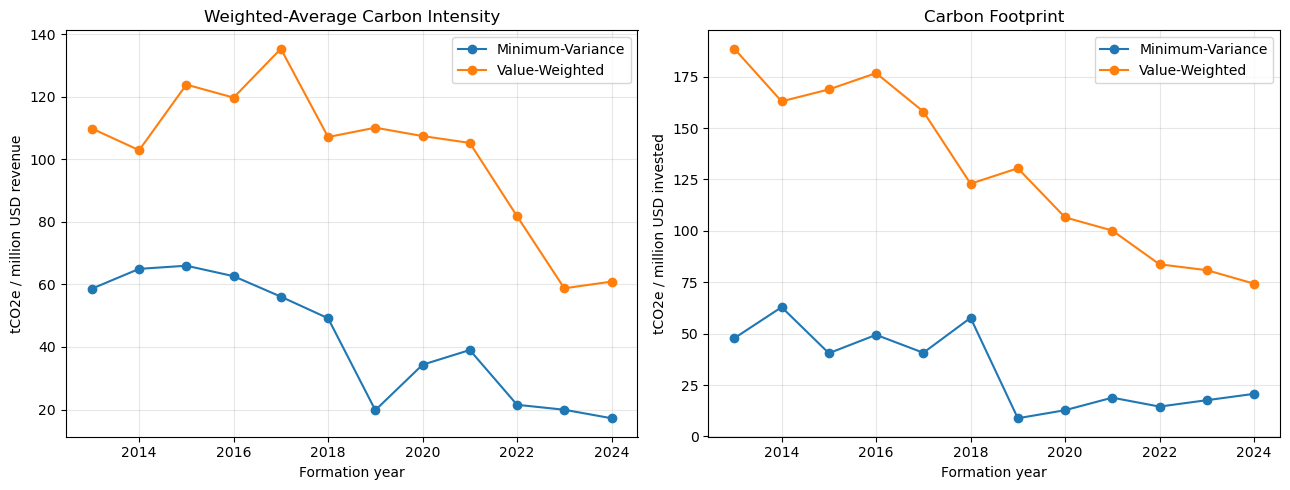

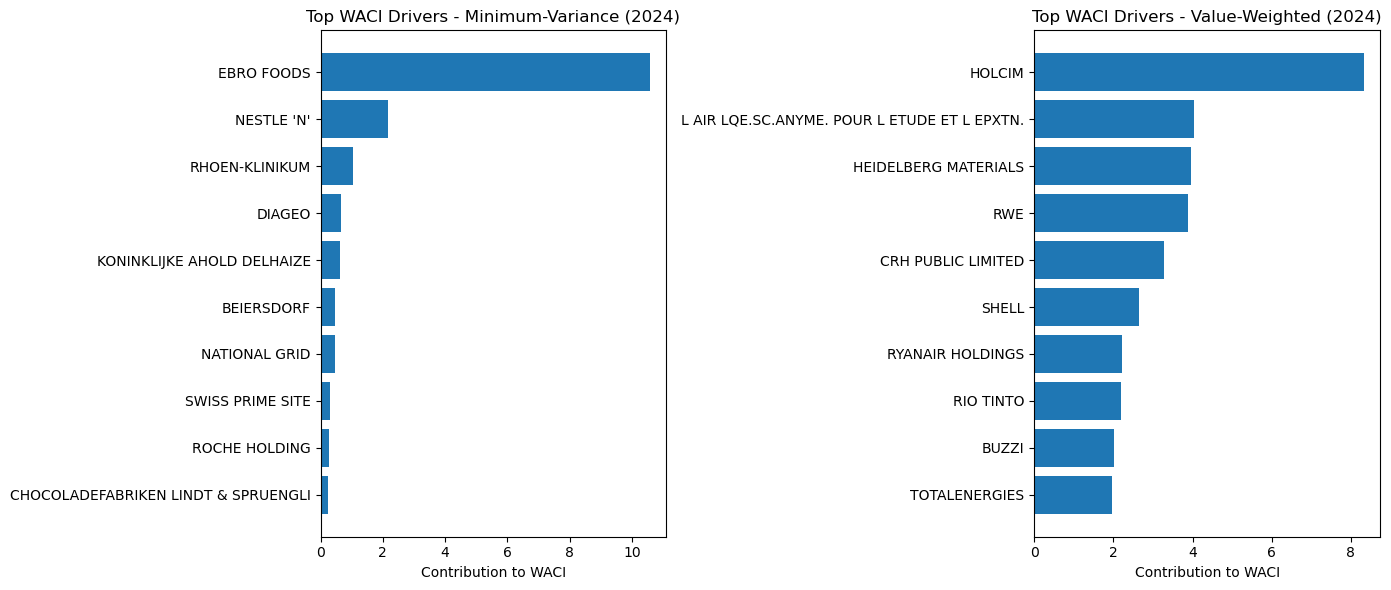

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for strategy, data in baseline_carbon_metrics.groupby("strategy"):
    axes[0].plot(data["formation_year"], data["WACI"], marker="o", label=strategy)
    axes[1].plot(data["formation_year"], data["carbon_footprint"], marker="o", label=strategy)

axes[0].set_title("Weighted-Average Carbon Intensity")
axes[0].set_xlabel("Formation year")
axes[0].set_ylabel("tCO2e / million USD revenue")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Carbon Footprint")
axes[1].set_xlabel("Formation year")
axes[1].set_ylabel("tCO2e / million USD invested")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "graph_baseline_waci_cf.png", dpi=300, bbox_inches="tight")
plt.show()

latest_top10 = top10_waci_drivers[top10_waci_drivers["formation_year"] == latest_year].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, strategy in zip(axes, ["Minimum-Variance", "Value-Weighted"]):
    data = latest_top10[latest_top10["strategy"] == strategy].copy()
    data = data.sort_values("WACI_contribution", ascending=True)
    ax.barh(data["NAME"], data["WACI_contribution"])
    ax.set_title(f"Top WACI Drivers - {strategy} ({latest_year})")
    ax.set_xlabel("Contribution to WACI")

plt.tight_layout()
plt.savefig(output_dir / "graph_top10_waci_drivers_latest_year.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation of baseline carbon metrics
The baseline plots compare carbon exposure before applying any decarbonization constraint. The top WACI table identifies the firms that contribute most to portfolio carbon intensity.


### 3.2) Long-Only Portfolio with a Carbon Footprint Objective
We now construct a long-only minimum-variance portfolio with a carbon footprint at least 50% lower than the unconstrained minimum-variance portfolio:

$$
CF_Y^p \leq 0.5 \times CF_Y^{MV}
$$

The optimization keeps the minimum-variance objective, full investment and no-short-selling constraints. The table below checks the annual carbon limit after optimization.


In [18]:
# MV50 keeps the variance objective and adds a carbon-footprint cap.
def solve_minvar_with_cf_constraint(cov_matrix, carbon_coeff, cf_limit):
    assets = cov_matrix.index.intersection(carbon_coeff.dropna().index)
    Sigma_df = cov_matrix.loc[assets, assets].copy()
    c = carbon_coeff.loc[assets].astype(float)

    valid_assets = Sigma_df.index[Sigma_df.notna().all(axis=1)]
    Sigma_df = Sigma_df.loc[valid_assets, valid_assets]
    c = c.loc[valid_assets]

    n = Sigma_df.shape[0]
    if n == 0:
        raise ValueError("No assets are available for the carbon-constrained optimization.")
    if c.min() > cf_limit + 1e-10:
        raise ValueError("The carbon footprint constraint is infeasible for this year.")

    Sigma = Sigma_df.to_numpy(dtype=float) + ridge * np.eye(n)
    c_vec = c.to_numpy(dtype=float)
    carbon_scale = max(abs(cf_limit), float(np.nanmax(np.abs(c_vec))), 1.0)

    clean_asset = np.zeros(n)
    clean_asset[int(np.argmin(c_vec))] = 1.0

    # If the MV start is infeasible, blend it toward the cleanest asset.
    try:
        x0 = solve_minvar(Sigma_df).reindex(Sigma_df.index).fillna(0.0).to_numpy(dtype=float)
        x0 = x0 / x0.sum()
    except Exception:
        x0 = np.repeat(1 / n, n)

    if float(x0 @ c_vec) > cf_limit:
        for lam in np.linspace(0, 1, 501):
            candidate = (1 - lam) * x0 + lam * clean_asset
            if float(candidate @ c_vec) <= cf_limit:
                x0 = candidate / candidate.sum()
                break

    def objective(w):
        return float(w @ Sigma @ w)

    def objective_grad(w):
        return 2.0 * Sigma @ w

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0, "jac": lambda w: np.ones_like(w)},
        {
            "type": "ineq",
            "fun": lambda w: (cf_limit - float(w @ c_vec)) / carbon_scale,
            "jac": lambda w: -c_vec / carbon_scale,
        },
    ]

    res = minimize(
        objective,
        x0=x0,
        jac=objective_grad,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=constraints,
        options={"maxiter": solver_maxiter * 5, "ftol": 1e-9, "disp": False},
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=Sigma_df.index)
    w[w < 1e-12] = 0.0
    return w / w.sum()

# Portfolio weights are fixed at formation, then drift monthly with returns.
def simulate_annual_strategy_returns(weights_by_year, strategy_name):
    rows = []
    all_months = sorted(ret_panel.columns)

    for Y in years:
        current_weights = normalize_weights(weights_by_year[Y])
        oos_months = [d for d in all_months if d.year == Y + 1]

        for dt in oos_months:
            r_t = ret_panel.loc[current_weights.index, dt].copy()

            if "delist_event_month" in globals():
                forced_delist_assets = []
                for asset in r_t.index:
                    if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                        forced_delist_assets.append(asset)
                if len(forced_delist_assets) > 0:
                    r_t.loc[forced_delist_assets] = -1.0

            valid = r_t.notna() & np.isfinite(r_t) & current_weights.notna()
            r_t = r_t[valid]
            w_t = current_weights[valid]

            if len(w_t) == 0:
                rows.append({"date": dt, "formation_year": Y, "oos_year": Y + 1, "portfolio_return": np.nan})
                continue

            w_t = w_t / w_t.sum()
            rp_t = float((w_t * r_t).sum())
            rows.append({"date": dt, "formation_year": Y, "oos_year": Y + 1, "portfolio_return": rp_t})

            denom = 1.0 + rp_t
            if abs(denom) > 1e-12:
                current_weights = w_t * (1.0 + r_t) / denom
                current_weights = current_weights / current_weights.sum()
            else:
                current_weights = pd.Series(np.repeat(1 / len(w_t), len(w_t)), index=w_t.index)

    monthly_returns = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    monthly_returns["date"] = pd.to_datetime(monthly_returns["date"])
    monthly_returns = monthly_returns[
        (monthly_returns["date"] >= pd.Timestamp("2014-01-01"))
        & (monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
    ].copy()
    monthly_returns["cumulative_index"] = (1.0 + monthly_returns["portfolio_return"]).cumprod()
    return monthly_returns

# Each year, the carbon limit is half of the baseline MV footprint.
mv50_weights = {}
mv50_constraint_rows = []

for Y in years:
    Sigma = sigma_dict[Y].copy()
    carbon_inputs = get_carbon_inputs(Sigma.index, Y)
    carbon_coeff = carbon_inputs["carbon_footprint_coeff"]

    mv_cf = compute_carbon_metrics(mv_weights[Y], Y, "Minimum-Variance")["carbon_footprint"]
    cf_limit = 0.5 * mv_cf
    w = solve_minvar_with_cf_constraint(Sigma, carbon_coeff, cf_limit)
    mv50_weights[Y] = w

    realized_cf = compute_carbon_metrics(w, Y, "Minimum-Variance 50% CF Reduction")["carbon_footprint"]
    mv50_constraint_rows.append({
        "formation_year": Y,
        "baseline_cf": mv_cf,
        "cf_limit": cf_limit,
        "realized_cf": realized_cf,
        "n_assets": len(w),
    })

mv50_constraint_check = pd.DataFrame(mv50_constraint_rows)
mv50_monthly_returns = simulate_annual_strategy_returns(mv50_weights, "Minimum-Variance 50% CF Reduction")
mv50_oos_returns = mv50_monthly_returns.set_index("date")["portfolio_return"].sort_index()
mv50_ex_post_te_vs_minvar = compute_ex_post_tracking_error(mv50_oos_returns, mv_oos_returns)
mv50_wealth_by_year = wealth_by_formation_year(mv50_oos_returns)

mv50_carbon_metrics = pd.DataFrame([
    compute_carbon_metrics(mv50_weights[Y], Y, "Minimum-Variance 50% CF Reduction", mv50_wealth_by_year[Y])
    for Y in years
])

minvar_50_returns = pd.concat(
    [mv_oos_returns.rename("Minimum-Variance"), mv50_oos_returns.rename("Minimum-Variance 50% CF Reduction")],
    axis=1,
).sort_index()

minvar_50_cumulative = (1.0 + minvar_50_returns).cumprod()
minvar_50_stats = pd.concat(
    [
        perf_stats(minvar_50_returns["Minimum-Variance"], rf_series).rename("Minimum-Variance"),
        perf_stats(minvar_50_returns["Minimum-Variance 50% CF Reduction"], rf_series).rename("Minimum-Variance 50% CF Reduction"),
    ],
    axis=1,
).T

minvar_50_stats["Ex-post tracking error vs benchmark"] = np.nan
minvar_50_stats.loc["Minimum-Variance", "Ex-post tracking error vs benchmark"] = 0.0
minvar_50_stats.loc["Minimum-Variance 50% CF Reduction", "Ex-post tracking error vs benchmark"] = mv50_ex_post_te_vs_minvar

mv50_weights_long = pd.concat(
    [w.rename("weight").reset_index().assign(formation_year=Y, oos_year=Y + 1) for Y, w in mv50_weights.items()],
    ignore_index=True,
)

display(mv50_constraint_check)
display(minvar_50_stats)


,formation_year,baseline_cf,cf_limit,realized_cf,n_assets
0,2013,47.811032,23.905516,23.905516,477
1,2014,62.889953,31.444977,31.444977,493
2,2015,40.486898,20.243449,20.243449,509
3,2016,49.422357,24.711178,24.711178,515
4,2017,40.695999,20.347999,20.347999,529
5,2018,57.688696,28.844348,28.844348,549
6,2019,8.845391,4.422695,4.422695,574
7,2020,12.763607,6.381804,6.381804,593
8,2021,18.863200,9.431600,9.431600,599
9,2022,14.515503,7.257752,7.257752,592


,Annualized mean return,Annualized volatility,Sharpe ratio,Minimum monthly return,Maximum monthly return,Final cumulative index,Maximum drawdown,Number of monthly observations,Ex-post tracking error vs benchmark
Minimum-Variance,0.057979,0.135722,0.298178,-0.116372,0.103969,1.792918,-0.276646,144.0,0.000000
Minimum-Variance 50% CF Reduction,0.057233,0.137007,0.289917,-0.121352,0.109511,1.773223,-0.282013,144.0,0.010378


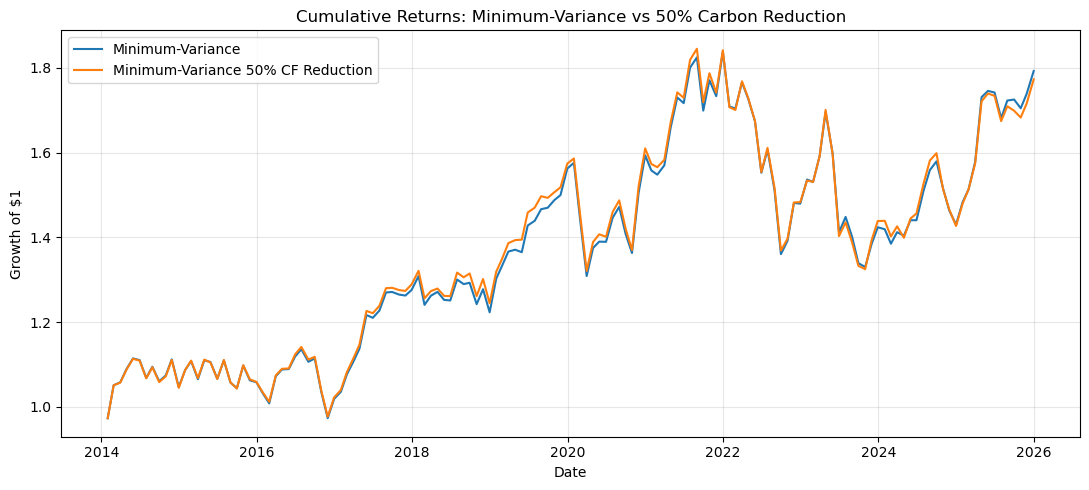

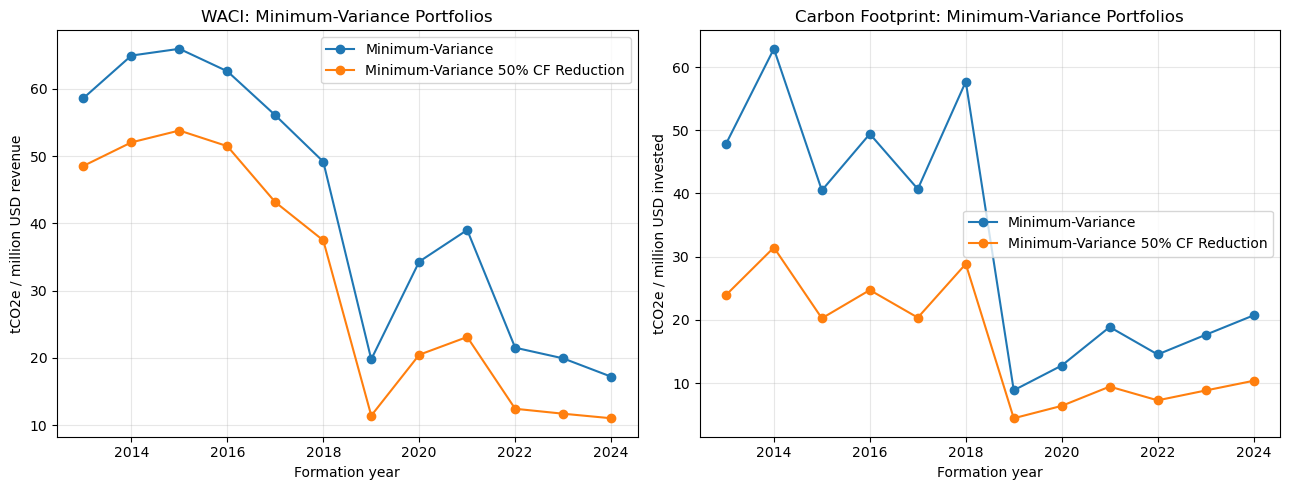

,change_type,ISIN,NAME,Minimum-Variance,Minimum-Variance 50% CF Reduction,weight_change
0,Most reduced,ES0112501012,EBRO FOODS,1.827013e-01,0.089857,-9.284398e-02
1,Most reduced,NL0011794037,KONINKLIJKE AHOLD DELHAIZE,3.587650e-02,0.000000,-3.587650e-02
2,Most reduced,DE0007042301,RHOEN-KLINIKUM,5.923016e-02,0.038913,-2.031716e-02
3,Most reduced,GB00BDR05C01,NATIONAL GRID,2.933933e-03,0.000000,-2.933933e-03
4,Most reduced,FR0000120644,DANONE,3.041836e-17,0.000000,-3.041836e-17
5,Most reduced,GB00B1FH8J72,SEVERN TRENT,1.333430e-17,0.000000,-1.333430e-17
6,Most reduced,AT0000720008,TELEKOM AUSTRIA,1.211330e-17,0.000000,-1.211330e-17
7,Most reduced,IE0004906560,KERRY GROUP 'A',1.104855e-17,0.000000,-1.104855e-17
8,Most reduced,GB0008025412,SIG,8.572217e-18,0.000000,-8.572217e-18
9,Most reduced,BE0974264930,AGEAS (EX-FORTIS),7.804720e-18,0.000000,-7.804720e-18


In [19]:
# Plot the MV carbon trade-off and inspect latest-year reallocations.
plt.figure(figsize=(11, 5))
for col in minvar_50_cumulative.columns:
    plt.plot(minvar_50_cumulative.index, minvar_50_cumulative[col], label=col)

plt.title("Cumulative Returns: Minimum-Variance vs 50% Carbon Reduction")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_minvar_50.png", dpi=300, bbox_inches="tight")
plt.show()

mv_carbon_compare = pd.concat(
    [baseline_carbon_metrics[baseline_carbon_metrics["strategy"] == "Minimum-Variance"], mv50_carbon_metrics],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for strategy, data in mv_carbon_compare.groupby("strategy"):
    axes[0].plot(data["formation_year"], data["WACI"], marker="o", label=strategy)
    axes[1].plot(data["formation_year"], data["carbon_footprint"], marker="o", label=strategy)

axes[0].set_title("WACI: Minimum-Variance Portfolios")
axes[0].set_xlabel("Formation year")
axes[0].set_ylabel("tCO2e / million USD revenue")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Carbon Footprint: Minimum-Variance Portfolios")
axes[1].set_xlabel("Formation year")
axes[1].set_ylabel("tCO2e / million USD invested")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "graph_carbon_minvar_50.png", dpi=300, bbox_inches="tight")
plt.show()

latest_mv = mv_weights[latest_year].rename("Minimum-Variance")
latest_mv50 = mv50_weights[latest_year].rename("Minimum-Variance 50% CF Reduction")
mv_composition_change = pd.concat([latest_mv, latest_mv50], axis=1).fillna(0)
mv_composition_change["weight_change"] = (
    mv_composition_change["Minimum-Variance 50% CF Reduction"] - mv_composition_change["Minimum-Variance"]
)
mv_composition_change = mv_composition_change.reset_index().sort_values("weight_change")

mv_reduced_names = (
    mv_composition_change
    .head(10)
    .assign(change_type="Most reduced")
)
mv_increased_names = (
    mv_composition_change
    .tail(10)
    .sort_values("weight_change", ascending=False)
    .assign(change_type="Most increased")
)

mv_latest_composition_changes = pd.concat([mv_reduced_names, mv_increased_names], ignore_index=True)
display(mv_latest_composition_changes[
    ["change_type", "ISIN", "NAME", "Minimum-Variance", "Minimum-Variance 50% CF Reduction", "weight_change"]
])


### Interpretation of the minimum-variance 50% reduction portfolio
The 50% carbon constraint can move the portfolio away from the unconstrained minimum-variance allocation. The composition table shows which holdings are reduced or increased the most in the latest formation year.


### 3.3) Tracking Error Minimization
This strategy starts from the value-weighted benchmark and minimizes tracking error while imposing a 50% carbon footprint reduction:

$$
CF_Y^p \leq 0.5 \times CF_Y^{VW}
$$

The notebook reports the optimized weights, the annual constraint checks, the ex-ante tracking error from the optimizer and the ex-post tracking error from realized monthly returns.


In [20]:
# VW50 minimizes tracking error to the benchmark under the carbon cap.
def solve_tracking_error_with_cf_constraint(cov_matrix, benchmark_weights, carbon_coeff, cf_limit):
    assets = cov_matrix.index.intersection(benchmark_weights.index).intersection(carbon_coeff.dropna().index)
    Sigma_df = cov_matrix.loc[assets, assets].copy()
    b = benchmark_weights.loc[assets].astype(float)
    c = carbon_coeff.loc[assets].astype(float)

    valid_assets = Sigma_df.index[Sigma_df.notna().all(axis=1)]
    Sigma_df = Sigma_df.loc[valid_assets, valid_assets]
    b = b.loc[valid_assets]
    c = c.loc[valid_assets]
    b = b / b.sum()

    n = Sigma_df.shape[0]
    if n == 0:
        raise ValueError("No assets are available for the tracking-error optimization.")
    if c.min() > cf_limit + 1e-10:
        raise ValueError("The carbon footprint constraint is infeasible for this year.")

    Sigma = Sigma_df.to_numpy(dtype=float) + ridge * np.eye(n)
    b_vec = b.to_numpy(dtype=float)
    c_vec = c.to_numpy(dtype=float)

    carbon_scale = max(abs(cf_limit), float(np.nanmax(np.abs(c_vec))), 1.0)

    clean_asset = np.zeros(n)
    clean_asset[int(np.argmin(c_vec))] = 1.0

    x0 = b_vec.copy()
    if float(x0 @ c_vec) > cf_limit:
        for lam in np.linspace(0, 1, 501):
            candidate = (1 - lam) * b_vec + lam * clean_asset
            if float(candidate @ c_vec) <= cf_limit:
                x0 = candidate / candidate.sum()
                break

    def objective(w):
        active = w - b_vec
        return float(active @ Sigma @ active)

    def objective_grad(w):
        active = w - b_vec
        return 2.0 * Sigma @ active

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0, "jac": lambda w: np.ones_like(w)},
        {
            "type": "ineq",
            "fun": lambda w: (cf_limit - float(w @ c_vec)) / carbon_scale,
            "jac": lambda w: -c_vec / carbon_scale,
        },
    ]

    res = minimize(
        objective,
        x0=x0,
        jac=objective_grad,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=constraints,
        options={"maxiter": solver_maxiter * 5, "ftol": 1e-9, "disp": False},
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=Sigma_df.index)
    w[w < 1e-12] = 0.0
    w = w / w.sum()

    te_monthly = np.sqrt(max(objective(w.to_numpy()), 0.0))
    te_annualized = np.sqrt(12) * te_monthly
    return w, te_annualized

# Each year starts from the value-weighted benchmark and imposes a 50% CF limit.
vw50_weights = {}
vw50_constraint_rows = []

for Y in years:
    Sigma = sigma_dict[Y].copy()
    eligible = investment_sets[Y]
    vw_w = get_annual_vw_weights(Y, eligible)
    carbon_inputs = get_carbon_inputs(Sigma.index, Y)
    carbon_coeff = carbon_inputs["carbon_footprint_coeff"]

    vw_cf = compute_carbon_metrics(vw_w, Y, "Value-Weighted")["carbon_footprint"]
    cf_limit = 0.5 * vw_cf
    w, te_ann = solve_tracking_error_with_cf_constraint(Sigma, vw_w, carbon_coeff, cf_limit)
    vw50_weights[Y] = w

    realized_cf = compute_carbon_metrics(w, Y, "Value-Weighted 50% CF Reduction")["carbon_footprint"]
    vw50_constraint_rows.append({
        "formation_year": Y,
        "benchmark_cf": vw_cf,
        "cf_limit": cf_limit,
        "realized_cf": realized_cf,
        "active_share_vs_benchmark": compute_active_share(w, vw_w),
        "ex_ante_tracking_error_annualized": te_ann,
        "n_assets": len(w),
    })

vw50_constraint_check = pd.DataFrame(vw50_constraint_rows)
vw50_monthly_returns = simulate_annual_strategy_returns(vw50_weights, "Value-Weighted 50% CF Reduction")
vw50_oos_returns = vw50_monthly_returns.set_index("date")["portfolio_return"].sort_index()
# Realized tracking error is measured on the out-of-sample monthly returns.
vw50_ex_post_te_vs_benchmark = compute_ex_post_tracking_error(vw50_oos_returns, vw_oos_returns)
vw50_constraint_check["ex_post_tracking_error_vs_benchmark"] = vw50_ex_post_te_vs_benchmark
vw50_wealth_by_year = wealth_by_formation_year(vw50_oos_returns)

vw50_carbon_metrics = pd.DataFrame([
    compute_carbon_metrics(vw50_weights[Y], Y, "Value-Weighted 50% CF Reduction", vw50_wealth_by_year[Y])
    for Y in years
])

vw_50_returns = pd.concat(
    [vw_oos_returns.rename("Value-Weighted"), vw50_oos_returns.rename("Value-Weighted 50% CF Reduction")],
    axis=1,
).sort_index()
vw_50_cumulative = (1.0 + vw_50_returns).cumprod()
vw_50_stats = pd.concat(
    [
        perf_stats(vw_50_returns["Value-Weighted"], rf_series).rename("Value-Weighted"),
        perf_stats(vw_50_returns["Value-Weighted 50% CF Reduction"], rf_series).rename("Value-Weighted 50% CF Reduction"),
    ],
    axis=1,
).T

vw_50_stats["Ex-post tracking error vs benchmark"] = np.nan
vw_50_stats.loc["Value-Weighted", "Ex-post tracking error vs benchmark"] = 0.0
vw_50_stats.loc["Value-Weighted 50% CF Reduction", "Ex-post tracking error vs benchmark"] = vw50_ex_post_te_vs_benchmark

vw50_weights_long = pd.concat(
    [w.rename("weight").reset_index().assign(formation_year=Y, oos_year=Y + 1) for Y, w in vw50_weights.items()],
    ignore_index=True,
)

display(vw50_constraint_check)
display(vw_50_stats)


,formation_year,benchmark_cf,cf_limit,realized_cf,active_share_vs_benchmark,ex_ante_tracking_error_annualized,n_assets,ex_post_tracking_error_vs_benchmark
0,2013,188.556022,94.278011,94.278011,0.038852,0.001703,477,0.008077
1,2014,162.995287,81.497643,81.497643,0.037787,0.001609,493,0.008077
2,2015,168.791124,84.395562,84.395562,0.033832,0.001497,509,0.008077
3,2016,176.735864,88.367932,88.367932,0.030638,0.001390,515,0.008077
4,2017,158.026717,79.013359,79.013359,0.035890,0.001579,529,0.008077
5,2018,122.924422,61.462211,61.462211,0.041252,0.001524,549,0.008077
6,2019,130.450278,65.225139,65.225139,0.051144,0.001175,574,0.008077
7,2020,106.562309,53.281155,53.281155,0.035590,0.001275,593,0.008077
8,2021,100.149566,50.074783,50.074783,0.035865,0.001341,599,0.008077
9,2022,83.720996,41.860498,41.860498,0.037970,0.001336,592,0.008077


,Annualized mean return,Annualized volatility,Sharpe ratio,Minimum monthly return,Maximum monthly return,Final cumulative index,Maximum drawdown,Number of monthly observations,Ex-post tracking error vs benchmark
Value-Weighted,0.080346,0.158463,0.397584,-0.152973,0.182863,2.253411,-0.283950,144.0,0.000000
Value-Weighted 50% CF Reduction,0.078684,0.160342,0.382549,-0.159519,0.188691,2.201391,-0.280938,144.0,0.008077


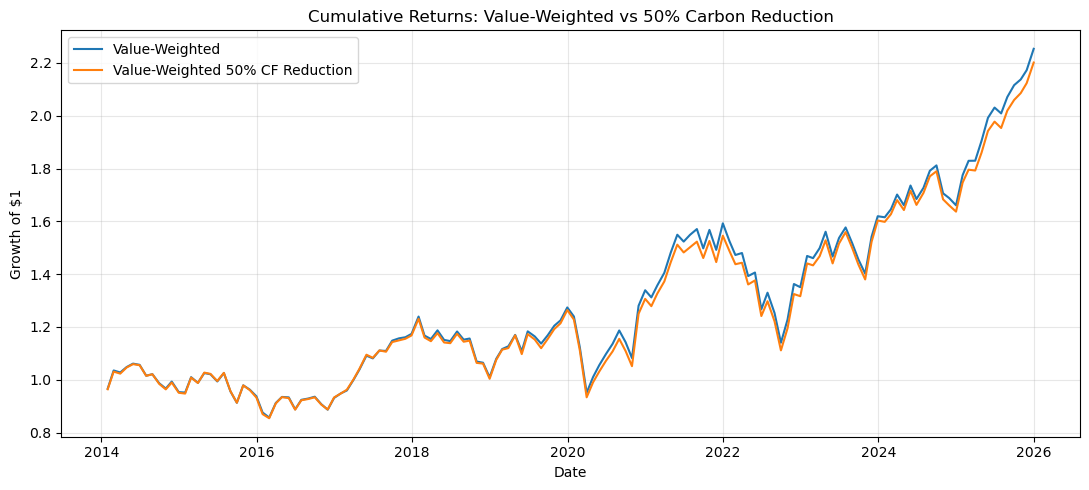

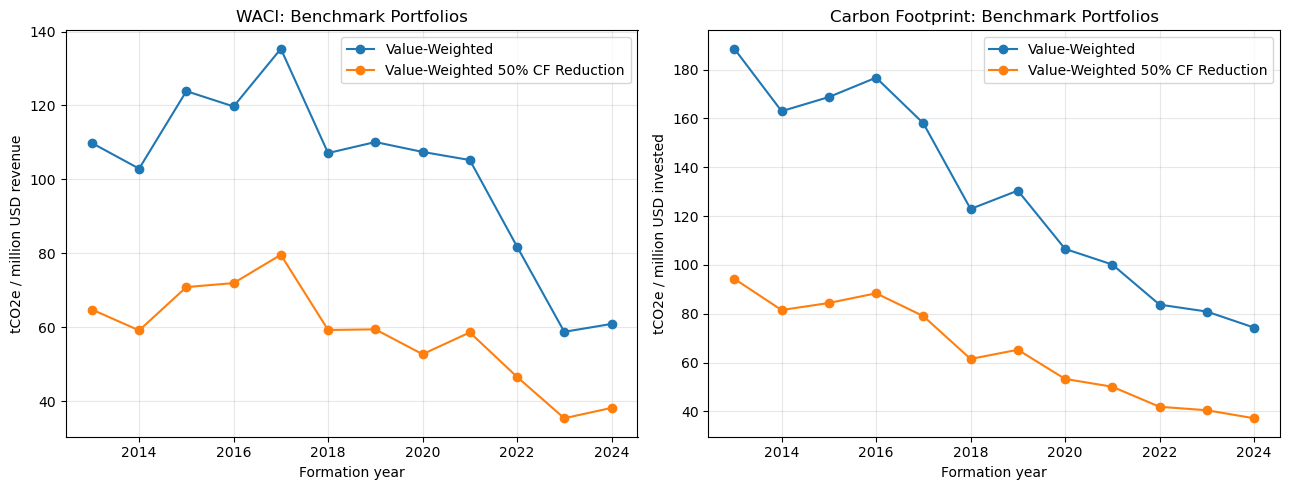

,change_type,ISIN,NAME,Value-Weighted,Value-Weighted 50% CF Reduction,weight_change
0,Most reduced,CH0012214059,HOLCIM,0.003656,0.001185,-0.002470
1,Most reduced,DE0007037129,RWE,0.002250,0.000788,-0.001462
2,Most reduced,DE0006047004,HEIDELBERG MATERIALS,0.001440,0.000000,-0.001440
3,Most reduced,ES0130670112,ENDESA,0.001713,0.000591,-0.001122
4,Most reduced,CH0038863350,NESTLE 'N',0.025347,0.024241,-0.001106
5,Most reduced,DK0010244508,A P MOLLER MAERSK B,0.001098,0.000000,-0.001098
6,Most reduced,FR0000124141,VEOLIA ENVIRON,0.001961,0.000873,-0.001088
7,Most reduced,DE0008232125,DEUTSCHE LUFTHANSA,0.000852,0.000000,-0.000852
8,Most reduced,CH0012032048,ROCHE HOLDING,0.015840,0.015087,-0.000753
9,Most reduced,NO0010208051,YARA INTERNATIONAL,0.000706,0.000000,-0.000706


In [21]:
# Plot the benchmark carbon trade-off and latest-year reallocations.
plt.figure(figsize=(11, 5))
for col in vw_50_cumulative.columns:
    plt.plot(vw_50_cumulative.index, vw_50_cumulative[col], label=col)

plt.title("Cumulative Returns: Value-Weighted vs 50% Carbon Reduction")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_vw_50.png", dpi=300, bbox_inches="tight")
plt.show()

vw_carbon_compare = pd.concat(
    [baseline_carbon_metrics[baseline_carbon_metrics["strategy"] == "Value-Weighted"], vw50_carbon_metrics],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for strategy, data in vw_carbon_compare.groupby("strategy"):
    axes[0].plot(data["formation_year"], data["WACI"], marker="o", label=strategy)
    axes[1].plot(data["formation_year"], data["carbon_footprint"], marker="o", label=strategy)

axes[0].set_title("WACI: Benchmark Portfolios")
axes[0].set_xlabel("Formation year")
axes[0].set_ylabel("tCO2e / million USD revenue")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Carbon Footprint: Benchmark Portfolios")
axes[1].set_xlabel("Formation year")
axes[1].set_ylabel("tCO2e / million USD invested")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "graph_carbon_vw_50.png", dpi=300, bbox_inches="tight")
plt.show()

latest_vw = vw_weights_by_year[latest_year].rename("Value-Weighted")
latest_vw50 = vw50_weights[latest_year].rename("Value-Weighted 50% CF Reduction")
vw_composition_change = pd.concat([latest_vw, latest_vw50], axis=1).fillna(0)
vw_composition_change["weight_change"] = (
    vw_composition_change["Value-Weighted 50% CF Reduction"] - vw_composition_change["Value-Weighted"]
)
vw_composition_change = vw_composition_change.reset_index().sort_values("weight_change")

vw_reduced_names = (
    vw_composition_change
    .head(10)
    .assign(change_type="Most reduced")
)
vw_increased_names = (
    vw_composition_change
    .tail(10)
    .sort_values("weight_change", ascending=False)
    .assign(change_type="Most increased")
)

vw_latest_composition_changes = pd.concat([vw_reduced_names, vw_increased_names], ignore_index=True)
display(vw_latest_composition_changes[
    ["change_type", "ISIN", "NAME", "Value-Weighted", "Value-Weighted 50% CF Reduction", "weight_change"]
])


### Interpretation of the value-weighted 50% reduction portfolio
This portfolio stays close to the value-weighted benchmark while meeting the 50% carbon footprint constraint. Active share and tracking error summarize how far the optimized portfolio moves away from the benchmark.


### 3.4) Comparison of Portfolios
This subsection compares the two 50% carbon reduction approaches. The minimum-variance version starts from a risk-optimized portfolio, while the value-weighted version starts from the market benchmark.
The comparison focuses on financial performance, carbon metrics and tracking error.


In [22]:
# Collect both 50% reduction strategies for side-by-side comparison.
all_50_stats = pd.concat([minvar_50_stats, vw_50_stats], axis=0)
all_50_carbon_metrics = pd.concat(
    [baseline_carbon_metrics, mv50_carbon_metrics, vw50_carbon_metrics],
    ignore_index=True,
)

display(all_50_stats)
display(all_50_carbon_metrics.head(12))


,Annualized mean return,Annualized volatility,Sharpe ratio,Minimum monthly return,Maximum monthly return,Final cumulative index,Maximum drawdown,Number of monthly observations,Ex-post tracking error vs benchmark
Minimum-Variance,0.057979,0.135722,0.298178,-0.116372,0.103969,1.792918,-0.276646,144.0,0.000000
Minimum-Variance 50% CF Reduction,0.057233,0.137007,0.289917,-0.121352,0.109511,1.773223,-0.282013,144.0,0.010378
Value-Weighted,0.080346,0.158463,0.397584,-0.152973,0.182863,2.253411,-0.283950,144.0,0.000000
Value-Weighted 50% CF Reduction,0.078684,0.160342,0.382549,-0.159519,0.188691,2.201391,-0.280938,144.0,0.008077


,strategy,formation_year,wealth_musd,WACI,carbon_footprint,attributed_emissions_tonnes,n_assets_used,n_assets_dropped
0,Minimum-Variance,2013,1.000000,58.638798,47.811032,47.811032,221,0
1,Value-Weighted,2013,1.000000,109.846954,188.556022,188.556022,477,0
2,Minimum-Variance,2014,1.046452,64.971390,62.889953,65.811299,233,0
3,Value-Weighted,2014,0.953306,102.903595,162.995287,155.384446,493,0
4,Minimum-Variance,2015,1.057855,65.976910,40.486898,42.829263,276,0
5,Value-Weighted,2015,0.937332,123.877002,168.791124,158.213297,509,0
6,Minimum-Variance,2016,1.018439,62.635664,49.422357,50.333653,280,0
7,Value-Weighted,2016,0.931324,119.726441,176.735864,164.598369,515,0
8,Minimum-Variance,2017,1.275633,56.089831,40.695999,51.913167,246,0
9,Value-Weighted,2017,1.173850,135.329496,158.026717,185.499619,529,0


### Interpretation of the 50% reduction comparison
The same carbon target has different effects depending on the starting portfolio. The comparison focuses on performance, drawdown, carbon reduction and tracking error.


## 4) Portfolio Allocation with a Net Zero Objective
The final strategy keeps the otherwise passive investor perspective. It minimizes tracking error relative to the value-weighted benchmark while imposing a carbon footprint path that declines by 10% per year from the initial 2013 benchmark footprint.


### 4.1) Net Zero Portfolio
For each formation year **Y**, the maximum allowed carbon footprint is:

$$
CF_Y^p \leq (1 - \theta)^{Y - Y_0 + 1} \times CF_{Y_0}^{VW}
$$

where $Y_0 = 2013$ and $\theta = 10\%$.
The optimization problem is the same tracking-error setup as in Section 3.3, but with this declining carbon budget.


In [23]:
# Net Zero target: carbon footprint falls by 10% per formation year.
theta = 0.10
Y0 = min(years)

initial_vw_cf = baseline_carbon_metrics[
    (baseline_carbon_metrics["strategy"] == "Value-Weighted")
    & (baseline_carbon_metrics["formation_year"] == Y0)
]["carbon_footprint"].iloc[0]

netzero_weights = {}
netzero_constraint_rows = []

# Stay close to the VW benchmark while meeting the declining carbon limit.
for Y in years:
    Sigma = sigma_dict[Y].copy()
    eligible = investment_sets[Y]
    vw_w = get_annual_vw_weights(Y, eligible)
    carbon_inputs = get_carbon_inputs(Sigma.index, Y)
    carbon_coeff = carbon_inputs["carbon_footprint_coeff"]

    vw_cf = compute_carbon_metrics(vw_w, Y, "Value-Weighted")["carbon_footprint"]
    cf_limit = ((1.0 - theta) ** (Y - Y0 + 1)) * initial_vw_cf
    w, te_ann = solve_tracking_error_with_cf_constraint(Sigma, vw_w, carbon_coeff, cf_limit)
    netzero_weights[Y] = w

    realized_cf = compute_carbon_metrics(w, Y, "Value-Weighted Net Zero")["carbon_footprint"]
    netzero_constraint_rows.append({
        "formation_year": Y,
        "benchmark_cf": vw_cf,
        "net_zero_cf_limit": cf_limit,
        "realized_cf": realized_cf,
        "active_share_vs_benchmark": compute_active_share(w, vw_w),
        "ex_ante_tracking_error_annualized": te_ann,
        "n_assets": len(w),
    })

netzero_constraint_check = pd.DataFrame(netzero_constraint_rows)
netzero_monthly_returns = simulate_annual_strategy_returns(netzero_weights, "Value-Weighted Net Zero")
netzero_oos_returns = netzero_monthly_returns.set_index("date")["portfolio_return"].sort_index()
# Realized tracking error is measured after the out-of-sample simulation.
netzero_ex_post_te_vs_benchmark = compute_ex_post_tracking_error(netzero_oos_returns, vw_oos_returns)
netzero_constraint_check["ex_post_tracking_error_vs_benchmark"] = netzero_ex_post_te_vs_benchmark
netzero_wealth_by_year = wealth_by_formation_year(netzero_oos_returns)

netzero_carbon_metrics = pd.DataFrame([
    compute_carbon_metrics(netzero_weights[Y], Y, "Value-Weighted Net Zero", netzero_wealth_by_year[Y])
    for Y in years
])

netzero_returns = pd.concat(
    [
        vw_oos_returns.rename("Value-Weighted"),
        vw50_oos_returns.rename("Value-Weighted 50% CF Reduction"),
        netzero_oos_returns.rename("Value-Weighted Net Zero"),
    ],
    axis=1,
).sort_index()

netzero_cumulative = (1.0 + netzero_returns).cumprod()
netzero_stats = pd.concat(
    [
        perf_stats(netzero_returns["Value-Weighted"], rf_series).rename("Value-Weighted"),
        perf_stats(netzero_returns["Value-Weighted 50% CF Reduction"], rf_series).rename("Value-Weighted 50% CF Reduction"),
        perf_stats(netzero_returns["Value-Weighted Net Zero"], rf_series).rename("Value-Weighted Net Zero"),
    ],
    axis=1,
).T

netzero_stats["Ex-post tracking error vs benchmark"] = np.nan
netzero_stats.loc["Value-Weighted", "Ex-post tracking error vs benchmark"] = 0.0
netzero_stats.loc["Value-Weighted 50% CF Reduction", "Ex-post tracking error vs benchmark"] = vw50_ex_post_te_vs_benchmark
netzero_stats.loc["Value-Weighted Net Zero", "Ex-post tracking error vs benchmark"] = netzero_ex_post_te_vs_benchmark

netzero_weights_long = pd.concat(
    [w.rename("weight").reset_index().assign(formation_year=Y, oos_year=Y + 1) for Y, w in netzero_weights.items()],
    ignore_index=True,
)

display(netzero_constraint_check)
display(netzero_stats)


,formation_year,benchmark_cf,net_zero_cf_limit,realized_cf,active_share_vs_benchmark,ex_ante_tracking_error_annualized,n_assets,ex_post_tracking_error_vs_benchmark
0,2013,188.556022,169.700420,169.700420,0.013112,0.000462,477,0.008286
1,2014,162.995287,152.730378,152.730378,0.008775,0.000337,493,0.008286
2,2015,168.791124,137.457340,137.457340,0.013966,0.000551,509,0.008286
3,2016,176.735864,123.711606,123.711606,0.019645,0.000741,515,0.008286
4,2017,158.026717,111.340445,111.340445,0.020186,0.000777,529,0.008286
5,2018,122.924422,100.206401,100.206401,0.016353,0.000519,549,0.008286
6,2019,130.450278,90.185761,90.185761,0.034178,0.000738,574,0.008286
7,2020,106.562309,81.167185,81.167185,0.022939,0.000653,593,0.008286
8,2021,100.149566,73.050466,73.050466,0.020525,0.000692,599,0.008286
9,2022,83.720996,65.745420,65.745420,0.017398,0.000527,592,0.008286


,Annualized mean return,Annualized volatility,Sharpe ratio,Minimum monthly return,Maximum monthly return,Final cumulative index,Maximum drawdown,Number of monthly observations,Ex-post tracking error vs benchmark
Value-Weighted,0.080346,0.158463,0.397584,-0.152973,0.182863,2.253411,-0.283950,144.0,0.000000
Value-Weighted 50% CF Reduction,0.078684,0.160342,0.382549,-0.159519,0.188691,2.201391,-0.280938,144.0,0.008077
Value-Weighted Net Zero,0.078891,0.160677,0.383041,-0.160118,0.188836,2.205404,-0.281114,144.0,0.008286


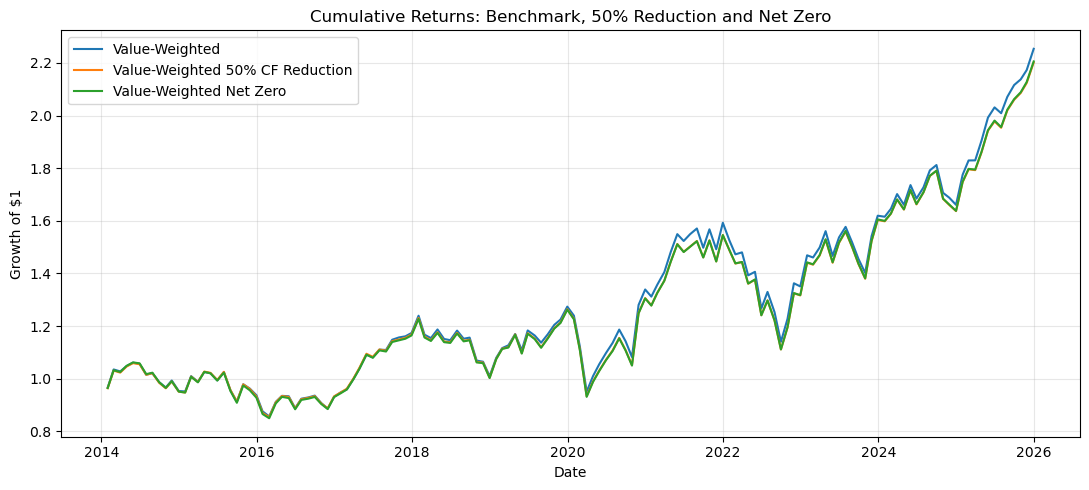

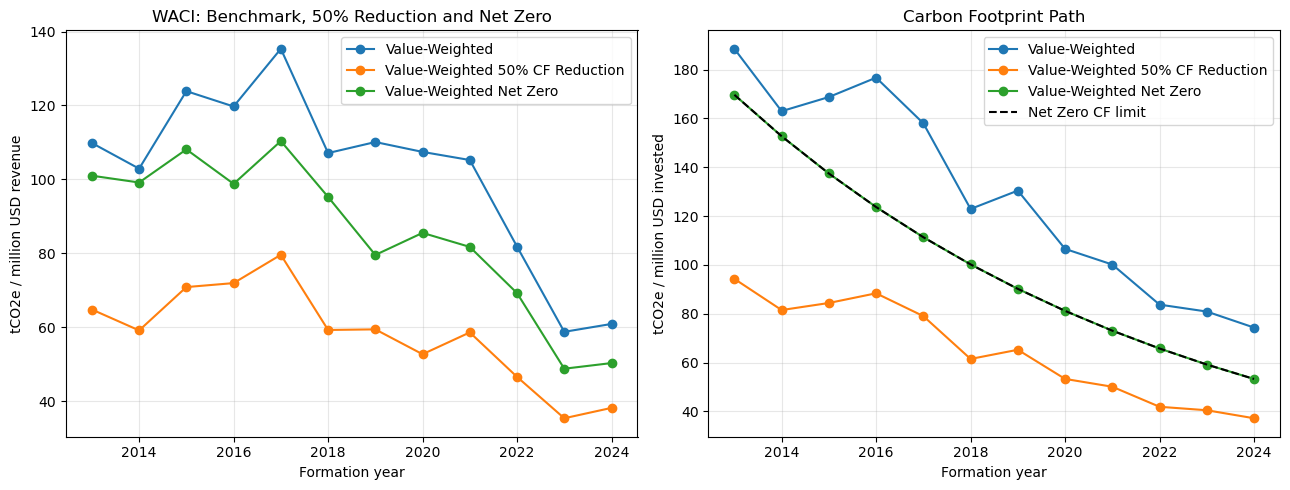

,change_type,ISIN,NAME,Value-Weighted,Value-Weighted Net Zero,weight_change
0,Most reduced,DE0006047004,HEIDELBERG MATERIALS,0.001440,3.901880e-04,-0.001049
1,Most reduced,CH0038863350,NESTLE 'N',0.025347,2.429894e-02,-0.001048
2,Most reduced,CH0012032048,ROCHE HOLDING,0.015840,1.518623e-02,-0.000654
3,Most reduced,IT0001347308,BUZZI,0.000537,2.032052e-07,-0.000537
4,Most reduced,GB0002374006,DIAGEO,0.006922,6.421038e-03,-0.000501
5,Most reduced,NO0010208051,YARA INTERNATIONAL,0.000706,2.227526e-04,-0.000483
6,Most reduced,CH0012214059,HOLCIM,0.003656,3.209056e-03,-0.000446
7,Most reduced,DE0008232125,DEUTSCHE LUFTHANSA,0.000852,4.358683e-04,-0.000416
8,Most reduced,DK0010244508,A P MOLLER MAERSK B,0.001098,6.869930e-04,-0.000411
9,Most reduced,AT0000937503,VOESTALPINE,0.000439,4.901449e-05,-0.000390


In [24]:
# Plot the Net Zero path and latest-year reallocations.
plt.figure(figsize=(11, 5))
for col in netzero_cumulative.columns:
    plt.plot(netzero_cumulative.index, netzero_cumulative[col], label=col)

plt.title("Cumulative Returns: Benchmark, 50% Reduction and Net Zero")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_netzero.png", dpi=300, bbox_inches="tight")
plt.show()

netzero_carbon_compare = pd.concat(
    [
        baseline_carbon_metrics[baseline_carbon_metrics["strategy"] == "Value-Weighted"],
        vw50_carbon_metrics,
        netzero_carbon_metrics,
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for strategy, data in netzero_carbon_compare.groupby("strategy"):
    axes[0].plot(data["formation_year"], data["WACI"], marker="o", label=strategy)
    axes[1].plot(data["formation_year"], data["carbon_footprint"], marker="o", label=strategy)

axes[1].plot(
    netzero_constraint_check["formation_year"],
    netzero_constraint_check["net_zero_cf_limit"],
    linestyle="--",
    color="black",
    label="Net Zero CF limit",
)

axes[0].set_title("WACI: Benchmark, 50% Reduction and Net Zero")
axes[0].set_xlabel("Formation year")
axes[0].set_ylabel("tCO2e / million USD revenue")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Carbon Footprint Path")
axes[1].set_xlabel("Formation year")
axes[1].set_ylabel("tCO2e / million USD invested")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "graph_carbon_netzero.png", dpi=300, bbox_inches="tight")
plt.show()

latest_netzero = netzero_weights[latest_year].rename("Value-Weighted Net Zero")
netzero_composition_change = pd.concat([latest_vw, latest_netzero], axis=1).fillna(0)
netzero_composition_change["weight_change"] = (
    netzero_composition_change["Value-Weighted Net Zero"] - netzero_composition_change["Value-Weighted"]
)
netzero_composition_change = netzero_composition_change.reset_index().sort_values("weight_change")

netzero_reduced_names = (
    netzero_composition_change
    .head(10)
    .assign(change_type="Most reduced")
)
netzero_increased_names = (
    netzero_composition_change
    .tail(10)
    .sort_values("weight_change", ascending=False)
    .assign(change_type="Most increased")
)

netzero_latest_composition_changes = pd.concat([netzero_reduced_names, netzero_increased_names], ignore_index=True)
display(netzero_latest_composition_changes[
    ["change_type", "ISIN", "NAME", "Value-Weighted", "Value-Weighted Net Zero", "weight_change"]
])


### Interpretation of the Net Zero portfolio
The dashed line in the carbon footprint graph shows the Net Zero target path. The results should be read together with active share, tracking error and cumulative performance.


### 4.2) Comparison of Portfolios
This subsection compares the value-weighted benchmark, the 50% reduction portfolio and the Net Zero portfolio. The final tables summarize performance, carbon metrics, constraint checks and latest-year composition changes.


In [25]:
# Consolidate final tables used by the report workbook.
final_carbon_metrics = pd.concat(
    [baseline_carbon_metrics, mv50_carbon_metrics, vw50_carbon_metrics, netzero_carbon_metrics],
    ignore_index=True,
)

final_stats = pd.concat([minvar_50_stats, netzero_stats], axis=0)
final_stats = final_stats[~final_stats.index.duplicated(keep="first")]

monthly_returns_all = pd.concat(
    [
        minvar_50_returns,
        netzero_returns[["Value-Weighted", "Value-Weighted 50% CF Reduction", "Value-Weighted Net Zero"]],
    ],
    axis=1,
).sort_index()

cumulative_returns_all = (1.0 + monthly_returns_all).cumprod()

mv50_constraints_clean = mv50_constraint_check.rename(
    columns={"baseline_cf": "benchmark_cf", "cf_limit": "carbon_limit"}
).copy()
mv50_constraints_clean.insert(0, "strategy", "Minimum-Variance 50% CF Reduction")

vw50_constraints_clean = vw50_constraint_check.rename(columns={"cf_limit": "carbon_limit"}).copy()
vw50_constraints_clean.insert(0, "strategy", "Value-Weighted 50% CF Reduction")

netzero_constraints_clean = netzero_constraint_check.rename(
    columns={"net_zero_cf_limit": "carbon_limit"}
).copy()
netzero_constraints_clean.insert(0, "strategy", "Value-Weighted Net Zero")

carbon_constraint_checks = pd.concat(
    [mv50_constraints_clean, vw50_constraints_clean, netzero_constraints_clean],
    ignore_index=True,
    sort=False,
)

carbon_summary_by_strategy = (
    final_carbon_metrics
    .groupby("strategy")
    .agg(
        avg_WACI=("WACI", "mean"),
        avg_carbon_footprint=("carbon_footprint", "mean"),
        first_carbon_footprint=("carbon_footprint", "first"),
        last_carbon_footprint=("carbon_footprint", "last"),
        first_year=("formation_year", "first"),
        last_year=("formation_year", "last"),
    )
    .reset_index()
)

composition_changes_latest_year = pd.concat(
    [
        mv_composition_change.assign(comparison="Minimum-Variance 50% CF Reduction"),
        vw_composition_change.assign(comparison="Value-Weighted 50% CF Reduction"),
        netzero_composition_change.assign(comparison="Value-Weighted Net Zero"),
    ],
    ignore_index=True,
    sort=False,
)

display(final_stats)
display(carbon_summary_by_strategy)


,Annualized mean return,Annualized volatility,Sharpe ratio,Minimum monthly return,Maximum monthly return,Final cumulative index,Maximum drawdown,Number of monthly observations,Ex-post tracking error vs benchmark
Minimum-Variance,0.057979,0.135722,0.298178,-0.116372,0.103969,1.792918,-0.276646,144.0,0.000000
Minimum-Variance 50% CF Reduction,0.057233,0.137007,0.289917,-0.121352,0.109511,1.773223,-0.282013,144.0,0.010378
Value-Weighted,0.080346,0.158463,0.397584,-0.152973,0.182863,2.253411,-0.283950,144.0,0.000000
Value-Weighted 50% CF Reduction,0.078684,0.160342,0.382549,-0.159519,0.188691,2.201391,-0.280938,144.0,0.008077
Value-Weighted Net Zero,0.078891,0.160677,0.383041,-0.160118,0.188836,2.205404,-0.281114,144.0,0.008286


,strategy,avg_WACI,avg_carbon_footprint,first_carbon_footprint,last_carbon_footprint,first_year,last_year
0,Minimum-Variance,42.442089,32.693331,47.811032,20.707678,2013,2024
1,Minimum-Variance 50% CF Reduction,31.395232,16.346666,23.905516,10.353839,2013,2024
2,Value-Weighted,101.923217,129.510078,188.556022,74.321040,2013,2024
3,Value-Weighted 50% CF Reduction,58.045291,64.755039,94.278011,37.160520,2013,2024
4,Value-Weighted Net Zero,85.656741,101.476674,169.700420,53.253790,2013,2024


## 5) Final checks and Excel workbook
This last step creates the clean Excel file used for review. It keeps only the useful tables and leaves the detailed calculations in the notebook.


In [26]:
from pathlib import Path
import re

from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter

final_dir = RESULTS_DIR / "final"
final_dir.mkdir(parents=True, exist_ok=True)
excel_file = final_dir / "SAAM_report_ready_outputs.xlsx"

def as_table(df):
    if isinstance(df.index, pd.RangeIndex):
        return df.copy()
    return df.reset_index()

def status_row(name, ok, value, target):
    return {
        "check": name,
        "status": "PASS" if ok else "CHECK",
        "value": value,
        "target": target,
    }

# Diagnostics keep the covariance shrinkage choice auditable.
shrinkage_rows = []
for Y in years:
    eigvals = np.linalg.eigvalsh(sigma_dict[Y].to_numpy(dtype=float))
    min_eig = eigvals.min()
    max_eig = eigvals.max()
    condition_number = max_eig / min_eig if min_eig > 0 else np.inf
    shrinkage_rows.append({
        "formation_year": Y,
        "shrinkage_alpha": shrinkage_alpha_by_year[Y],
        "min_covariance_eigenvalue": min_eig,
        "max_covariance_eigenvalue": max_eig,
        "condition_number": condition_number,
        "covariance_assets": sigma_dict[Y].shape[0],
    })

shrinkage_diagnostics = pd.DataFrame(shrinkage_rows)

# Lightweight checks for the final strategy tables.
checks = []
checks.append(status_row("Monthly observations", monthly_returns_all.shape[0] == 144, monthly_returns_all.shape[0], "144"))
checks.append(status_row("Missing monthly returns", monthly_returns_all.isna().sum().sum() == 0, int(monthly_returns_all.isna().sum().sum()), "0"))

weight_sets = {
    "Minimum-Variance": mv_weights,
    "Minimum-Variance 50% CF Reduction": mv50_weights,
    "Value-Weighted": vw_weights_by_year,
    "Value-Weighted 50% CF Reduction": vw50_weights,
    "Value-Weighted Net Zero": netzero_weights,
}

for name, weights_by_year in weight_sets.items():
    max_sum_error = max(abs(normalize_weights(w).sum() - 1.0) for w in weights_by_year.values())
    min_weight = min(normalize_weights(w).min() for w in weights_by_year.values())
    checks.append(status_row(f"{name}: weights sum to one", max_sum_error < 1e-8, max_sum_error, "< 1e-8"))
    checks.append(status_row(f"{name}: long-only weights", min_weight >= -1e-10, min_weight, ">= 0"))

max_carbon_breach = (carbon_constraint_checks["realized_cf"] - carbon_constraint_checks["carbon_limit"]).max()
checks.append(status_row("Carbon constraints", max_carbon_breach <= 1e-7, max_carbon_breach, "<= 1e-7"))
checks.append(status_row(
    "Shrinkage alpha range",
    shrinkage_diagnostics["shrinkage_alpha"].between(0, 1).all(),
    f"{shrinkage_diagnostics['shrinkage_alpha'].min():.4f} - {shrinkage_diagnostics['shrinkage_alpha'].max():.4f}",
    "[0, 1]",
))
checks.append(status_row(
    "Covariance matrix eigenvalues",
    shrinkage_diagnostics["min_covariance_eigenvalue"].min() >= -1e-10,
    shrinkage_diagnostics["min_covariance_eigenvalue"].min(),
    ">= 0",
))

validation_checks = pd.DataFrame(checks)

universe_rows = []
for Y in years:
    row = {
        "formation_year": Y,
        "eligible_firms": len(investment_sets[Y]),
        "covariance_assets": sigma_dict[Y].shape[0],
    }
    for name, weights_by_year in weight_sets.items():
        w = normalize_weights(weights_by_year[Y])
        row[f"{name} positive_weights"] = int((w > 1e-6).sum())
        row[f"{name} effective_n"] = 1.0 / (w.pow(2).sum())
        row[f"{name} max_weight"] = w.max()
    universe_rows.append(row)
universe_diagnostics = pd.DataFrame(universe_rows)

def top_weights(weights_by_year, strategy, n=10):
    rows = []
    for Y, weights in weights_by_year.items():
        for asset, weight in normalize_weights(weights).sort_values(ascending=False).head(n).items():
            isin, name = asset
            rows.append({"strategy": strategy, "formation_year": Y, "ISIN": isin, "NAME": name, "weight": weight})
    return pd.DataFrame(rows)

top_weights_by_year = pd.concat(
    [top_weights(weights, name) for name, weights in weight_sets.items()],
    ignore_index=True,
)

def cf_contributions(weights, Y, strategy):
    weights = normalize_weights(weights)
    carbon = get_carbon_inputs(weights.index, Y)
    w = weights.reindex(carbon.index).dropna()
    carbon = carbon.loc[w.index]
    w = w / w.sum()

    out = carbon.copy()
    out["weight"] = w
    out["carbon_footprint_contribution"] = out["weight"] * out["carbon_footprint_coeff"]
    total = out["carbon_footprint_contribution"].sum()
    out["carbon_footprint_share"] = out["carbon_footprint_contribution"] / total
    out = out.reset_index()
    out["formation_year"] = Y
    out["strategy"] = strategy
    return out

top_cf_tables = []
top_waci_tables = []
for name, weights_by_year in weight_sets.items():
    for Y in years:
        top_cf_tables.append(cf_contributions(weights_by_year[Y], Y, name))
        top_waci_tables.append(compute_waci_contributions(weights_by_year[Y], Y, name))

top_cf_drivers = (
    pd.concat(top_cf_tables, ignore_index=True)
    .sort_values(["strategy", "formation_year", "carbon_footprint_contribution"], ascending=[True, True, False])
    .groupby(["strategy", "formation_year"])
    .head(10)
    .reset_index(drop=True)
)

top_waci_drivers = (
    pd.concat(top_waci_tables, ignore_index=True)
    .sort_values(["strategy", "formation_year", "WACI_contribution"], ascending=[True, True, False])
    .groupby(["strategy", "formation_year"])
    .head(10)
    .reset_index(drop=True)
)

def compact_changes(df, base_col, new_col, label, n=25):
    out = df[["ISIN", "NAME", base_col, new_col, "weight_change"]].copy()
    out.insert(0, "comparison", label)
    out["abs_weight_change"] = out["weight_change"].abs()
    return out.sort_values("abs_weight_change", ascending=False).head(n)

composition_changes_compact = pd.concat(
    [
        compact_changes(mv_composition_change, "Minimum-Variance", "Minimum-Variance 50% CF Reduction", "Minimum-Variance 50% CF Reduction"),
        compact_changes(vw_composition_change, "Value-Weighted", "Value-Weighted 50% CF Reduction", "Value-Weighted 50% CF Reduction"),
        compact_changes(netzero_composition_change, "Value-Weighted", "Value-Weighted Net Zero", "Value-Weighted Net Zero"),
    ],
    ignore_index=True,
)

te_diagnostics = carbon_constraint_checks[
    carbon_constraint_checks["strategy"].isin(["Value-Weighted 50% CF Reduction", "Value-Weighted Net Zero"])
].copy()
te_diagnostics["ex_post_to_ex_ante_TE"] = (
    te_diagnostics["ex_post_tracking_error_vs_benchmark"]
    / te_diagnostics["ex_ante_tracking_error_annualized"]
)

# Workbook tabs kept for reporting or audit.
sheets = {
    "Performance": as_table(final_stats.rename_axis("strategy")),
    "Carbon_summary": carbon_summary_by_strategy,
    "Carbon_by_year": final_carbon_metrics,
    "Constraints": carbon_constraint_checks,
    "Validation": validation_checks,
    "Shrinkage_diagnostics": shrinkage_diagnostics,
    "Universe": universe_diagnostics,
    "TE_diagnostics": te_diagnostics,
    "Top_weights": top_weights_by_year,
    "Top_CF_drivers": top_cf_drivers,
    "Top_WACI_drivers": top_waci_drivers,
    "Composition_changes": composition_changes_compact,
    "Monthly_returns": as_table(monthly_returns_all.rename_axis("date")),
    "Cumulative_returns": as_table(cumulative_returns_all.rename_axis("date")),
}

# Write a plain formatted workbook.
with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    for sheet_name, df in sheets.items():
        df.copy().to_excel(writer, sheet_name=sheet_name[:31], index=False)

    header_fill = PatternFill("solid", fgColor="1F4E78")
    header_font = Font(color="FFFFFF", bold=True)

    for ws in writer.book.worksheets:
        ws.freeze_panes = "A2"
        ws.sheet_view.showGridLines = False
        ws.auto_filter.ref = ws.dimensions

        for cell in ws[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for col in ws.columns:
            col_letter = get_column_letter(col[0].column)
            header = str(col[0].value or "").lower()
            width = min(max(len(str(c.value)) if c.value is not None else 0 for c in col[:200]) + 2, 42)
            ws.column_dimensions[col_letter].width = max(width, 10)

            for cell in col[1:]:
                if isinstance(cell.value, (int, float)):
                    if any(key in header for key in ["return", "volatility", "drawdown", "tracking_error", "weight", "active_share", "share"]):
                        cell.number_format = "0.00%"
                    elif any(key in header for key in ["year", "observations", "n_assets", "firms"]):
                        cell.number_format = "0"
                    else:
                        cell.number_format = "#,##0.0000"

display(validation_checks)
display(shrinkage_diagnostics)


,check,status,value,target
0,Monthly observations,PASS,144,144
1,Missing monthly returns,PASS,0,0
2,Minimum-Variance: weights sum to one,PASS,0.0,< 1e-8
3,Minimum-Variance: long-only weights,PASS,0.0,>= 0
4,Minimum-Variance 50% CF Reduction: weights sum...,PASS,0.0,< 1e-8
5,Minimum-Variance 50% CF Reduction: long-only w...,PASS,0.000016,>= 0
6,Value-Weighted: weights sum to one,PASS,0.0,< 1e-8
7,Value-Weighted: long-only weights,PASS,0.000004,>= 0
8,Value-Weighted 50% CF Reduction: weights sum t...,PASS,0.0,< 1e-8
9,Value-Weighted 50% CF Reduction: long-only wei...,PASS,0.0,>= 0


,formation_year,shrinkage_alpha,min_covariance_eigenvalue,max_covariance_eigenvalue,condition_number,covariance_assets
0,2013,1.000000,0.001185,2.181767,1841.293681,477
1,2014,1.000000,0.001169,2.224003,1902.478172,493
2,2015,1.000000,0.001199,2.369714,1977.196622,509
3,2016,0.978952,0.001258,2.453874,1951.167016,515
4,2017,0.975131,0.001240,2.494130,2012.204028,529
5,2018,0.806916,0.001016,2.083247,2049.530906,549
6,2019,0.470886,0.000549,1.621253,2952.970732,574
7,2020,0.792187,0.000887,2.098580,2365.795142,593
8,2021,0.850315,0.000969,1.913394,1975.485757,600
9,2022,0.799871,0.000991,2.011941,2030.917724,592


### Final output
The notebook finishes by exporting one consolidated Excel workbook and the figures generated throughout the analysis.
The workbook contains the tables used for the final comparison: performance statistics, yearly carbon metrics, constraint checks, tracking-error diagnostics, top carbon contributors and latest-year composition changes.
The five strategies are kept side by side so that the financial and carbon outcomes can be compared directly.
